In [ ]:
import pandas as pd

# --- 1. Data Loading and Preprocessing (Modified for your format) ---
def load_and_preprocess_data(file_path_or_buffer):
    """
    Loads data from a CSV, pivots it into a wide format, and handles missing values.
    """
    print("  Loading and preprocessing data...")
    df = pd.read_csv(file_path_or_buffer, sep=',')
    
    # Step 1: Create a single datetime index and sort
    df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['time']) + pd.to_timedelta(df['seconds'], unit='s')
    df = df.sort_values('timestamp').drop_duplicates()
    
    # Step 2: Pivot the DataFrame from long to wide format
    # Rows will be timestamps, columns will be sensors, values will be the 'state'
    wide_df = df.pivot_table(index='timestamp', columns='sensor_name', values='state', aggfunc='mean')
    
    # Step 3: Handle missing values using forward-fill
    # This carries the last known sensor state forward
    wide_df = wide_df.ffill().bfill() # bfill handles initial NaNs
    
    # Step 4: Convert to NumPy array
    sensor_names = wide_df.columns.tolist()
    data_array = wide_df.values
    
    print(f"  Data preprocessed successfully. Found {data_array.shape[1]} sensors.")
    return data_array, sensor_names

# data_array, sensor_names = load_and_preprocess_data('Data\Lab_Data\sead_anomaly_free_lab_data_1h.csv')
data_array, sensor_names = load_and_preprocess_data('Data/Office_Data/sead_anomaly_free_office_data_13-01-25_to_13-02-25_1h.csv')

ÃƒÂ°Ã…Â¸Ã¢â‚¬ÂÃ¢â‚¬Å¾ Loading and preprocessing data...
ÃƒÂ¢Ã…â€œÃ¢â‚¬Â¦ Data preprocessed successfully. Found 4 sensors.


In [9]:
print(f"Data shape: {data_array.shape}, {sensor_names} sensors loaded, sample data:\n{data_array[:5]}")

Data shape: (33471, 4), ['Desk Motion Sensor', 'Office Door Motion Sensor', 'Office Door Sensor', 'Office Light Sensor'] sensors loaded, sample data:
[[1. 1. 1. 1.]
 [1. 0. 1. 1.]
 [1. 1. 1. 1.]
 [1. 0. 1. 1.]
 [1. 1. 1. 1.]]


In [6]:
adj_df = pd.read_csv('Data/adjacency_matrices/office_fne_matrix_norm.csv', index_col=0)
print(f"Adjacency matrix shape: {adj_df.shape}, sample data:\n{adj_df.values[:5, :5]}")

Adjacency matrix shape: (4, 4), sample data:
[[0.         1.         0.         0.02580964]
 [1.         0.         0.         0.16087149]
 [0.         0.         0.         0.        ]
 [0.         1.         0.         0.        ]]


In [ ]:

import numpy as np
import torch
# ============================================================
# COMPLEX ANOMALY INJECTION
# Six anomaly types distributed evenly across num_anomalies.
# Signature matches inject_selective_anomalies:
#   inject_complex_anomalies(data, edge_index, ...) -> (anomalous_data, labels)
#
# Types:
#   I.   Spike            – sensor → 1.0 for a random window
#   II.  Dropout          – sensor → 0.0 for a random window
#   III. Mixed            – 2-3 sensors, each randomly spiked or dropped, same window
#   IV.  Corr. violation  – two connected sensors forced to opposite extremes (8 steps)
#   V.   Neighbor incons  – sensor → opposite of neighbors' mean (5 steps)
#   VI.  Collective       – connected subgraph shifts opposite to boundary neighbors
# ============================================================

def inject_complex_anomalies(data, edge_index, num_anomalies=50,
                              min_duration=10, max_duration=40,
                              window_size=4, seed=None):
    """
    Injects a mixture of six anomaly types into the data.

    Parameters
    ----------
    data        : np.ndarray, shape (n_timesteps, n_sensors)
    edge_index  : torch.Tensor or array-like, shape (2, E) — graph adjacency
    num_anomalies : total anomalies to inject, distributed evenly across types
    min_duration  : minimum window length (floor-clamped to window_size)
    max_duration  : maximum window length (exclusive)
    window_size   : sliding window size; each anomaly spans >= this many steps
    seed          : optional numpy RNG seed for reproducibility

    Returns
    -------
    anomalous_data : np.ndarray, same shape as data
    labels         : np.ndarray, shape (n_timesteps,), 1 at anomalous timesteps
    """
    if seed is not None:
        np.random.seed(seed)

    n_steps, n_sensors = data.shape
    anomalous_data = data.copy().astype(np.float32)
    labels   = np.zeros(n_steps, dtype=np.float32)
    occupied = np.zeros(n_steps, dtype=bool)

    # ---- Build undirected adjacency list (self-loops excluded) ----
    _ei = (edge_index.cpu().numpy()
           if isinstance(edge_index, torch.Tensor)
           else np.array(edge_index))

    adj = {i: set() for i in range(n_sensors)}
    for k in range(_ei.shape[1]):
        s, d = int(_ei[0, k]), int(_ei[1, k])
        if s != d:
            adj[s].add(d)
            adj[d].add(s)

    undirected_edges = sorted({
        (min(s, d), max(s, d))
        for s in range(n_sensors)
        for d in adj[s]
    })
    sensors_w_neighbors = [s for s in range(n_sensors) if adj[s]]

    # ---- Distribute num_anomalies evenly across 6 types ----
    base   = num_anomalies // 6
    extras = num_anomalies % 6
    counts = [base + (1 if i < extras else 0) for i in range(6)]

    # Redistribute graph-based budgets if connectivity is insufficient
    if not undirected_edges:
        counts[0] += counts[3] + counts[4] + counts[5]
        counts[3] = counts[4] = counts[5] = 0
    elif not sensors_w_neighbors:
        counts[0] += counts[4] + counts[5]
        counts[4] = counts[5] = 0

    eff_min  = max(min_duration, window_size)
    MAX_ITER = num_anomalies * 25

    def _can_place(start, dur):
        return (start >= 0 and start + dur <= n_steps
                and not occupied[start:start + dur].any())

    def _mark(start, dur):
        labels[start:start + dur]   = 1
        occupied[start:start + dur] = True

    placed = [0] * 6

    # ---- I. Spike: sensor → 1.0 ----
    _t = 0
    while placed[0] < counts[0] and _t < MAX_ITER:
        _t += 1
        dur   = np.random.randint(eff_min, max(eff_min + 1, max_duration))
        start = np.random.randint(0, max(1, n_steps - dur))
        s     = np.random.randint(n_sensors)
        if _can_place(start, dur):
            anomalous_data[start:start + dur, s] = 1.0
            _mark(start, dur)
            placed[0] += 1

    # ---- II. Dropout: sensor → 0.0 ----
    _t = 0
    while placed[1] < counts[1] and _t < MAX_ITER:
        _t += 1
        dur   = np.random.randint(eff_min, max(eff_min + 1, max_duration))
        start = np.random.randint(0, max(1, n_steps - dur))
        s     = np.random.randint(n_sensors)
        if _can_place(start, dur):
            anomalous_data[start:start + dur, s] = 0.0
            _mark(start, dur)
            placed[1] += 1

    # ---- III. Mixed: 2-3 sensors, each randomly spiked or dropped ----
    _t = 0
    while placed[2] < counts[2] and _t < MAX_ITER:
        _t += 1
        dur   = np.random.randint(eff_min, max(eff_min + 1, max_duration))
        start = np.random.randint(0, max(1, n_steps - dur))
        n_aff = np.random.randint(2, min(4, n_sensors) + 1)
        sel   = np.random.choice(n_sensors, size=n_aff, replace=False)
        if _can_place(start, dur):
            for s in sel:
                anomalous_data[start:start + dur, s] = (
                    1.0 if np.random.random() > 0.5 else 0.0
                )
            _mark(start, dur)
            placed[2] += 1

    # ---- IV. Correlation violation: connected pair diverges around shared mean ----
    # Fixed 8-step window (floor-clamped to window_size).
    _iv_dur = max(8, window_size)
    _t = 0
    while placed[3] < counts[3] and _t < MAX_ITER and undirected_edges:
        _t += 1
        s_a, s_b = undirected_edges[np.random.randint(len(undirected_edges))]
        start    = np.random.randint(0, max(1, n_steps - _iv_dur))
        if _can_place(start, _iv_dur):
            # Shared mean in original data; diverge sensor_a up / sensor_b down (or vice versa)
            mean_ab = (data[start:start + _iv_dur, s_a].mean() +
                       data[start:start + _iv_dur, s_b].mean()) / 2.0
            if mean_ab >= 0.5:
                anomalous_data[start:start + _iv_dur, s_a] = 1.0
                anomalous_data[start:start + _iv_dur, s_b] = 0.0
            else:
                anomalous_data[start:start + _iv_dur, s_a] = 0.0
                anomalous_data[start:start + _iv_dur, s_b] = 1.0
            _mark(start, _iv_dur)
            placed[3] += 1

    # ---- V. Neighbor inconsistency: target → opposite of neighbors' mean ----
    # Fixed 5-step window (floor-clamped to window_size).
    _v_dur = max(5, window_size)
    _t = 0
    while placed[4] < counts[4] and _t < MAX_ITER and sensors_w_neighbors:
        _t += 1
        target    = sensors_w_neighbors[np.random.randint(len(sensors_w_neighbors))]
        neighbors = list(adj[target])
        start     = np.random.randint(0, max(1, n_steps - _v_dur))
        if _can_place(start, _v_dur):
            # Neighbor mean over the window (original data) — push target to the other extreme
            nb_mean = data[start:start + _v_dur, neighbors].mean()
            anomalous_data[start:start + _v_dur, target] = (
                0.0 if nb_mean >= 0.5 else 1.0
            )
            _mark(start, _v_dur)
            placed[4] += 1

    # ---- VI. Collective anomaly: connected subgraph shifts vs. boundary neighbors ----
    def _bfs_subgraph(root, size):
        """BFS: collect up to `size` connected nodes starting from `root`."""
        visited, queue = [root], [root]
        while len(visited) < size and queue:
            cur = queue.pop(0)
            for nb in adj[cur]:
                if nb not in visited:
                    visited.append(nb)
                    queue.append(nb)
                    if len(visited) >= size:
                        break
        return visited if len(visited) >= 2 else None

    _t = 0
    while placed[5] < counts[5] and _t < MAX_ITER and sensors_w_neighbors:
        _t += 1
        size     = np.random.randint(2, min(5, n_sensors + 1))
        root     = sensors_w_neighbors[np.random.randint(len(sensors_w_neighbors))]
        subgraph = _bfs_subgraph(root, size)
        if subgraph is None:
            continue
        sub_set  = set(subgraph)
        # External boundary: sensors connected to the subgraph but not in it
        boundary = {nb for s in subgraph for nb in adj[s] if nb not in sub_set}
        dur      = np.random.randint(eff_min, max(eff_min + 1, max_duration))
        start    = np.random.randint(0, max(1, n_steps - dur))
        if not _can_place(start, dur):
            continue
        # Reference direction from original data
        ref_nodes = list(boundary) if boundary else subgraph
        ref_mean  = data[start:start + dur, ref_nodes].mean()
        # Shift entire subgraph to the opposite extreme of the reference
        shift_val = 0.0 if ref_mean >= 0.5 else 1.0
        for s in subgraph:
            anomalous_data[start:start + dur, s] = shift_val
        _mark(start, dur)
        placed[5] += 1

    # ---- Summary ----
    type_names = [
        'I.   spike           ',
        'II.  dropout         ',
        'III. mixed           ',
        'IV.  corr_violation  ',
        'V.   neighbor_incons ',
        'VI.  collective      ',
    ]
    print("inject_complex_anomalies — results:")
    for name, p, c in zip(type_names, placed, counts):
        status = '' if p == c else f'  (WARNING: only {p}/{c} placed)'
        print(f"  {name}: {p:3d}/{c}{status}")
    total = sum(placed)
    if total < num_anomalies:
        print(f"  NOTE: {num_anomalies - total} anomalies could not be placed "
              f"(test segment too short or density too high)")
    print(f"  Total placed: {total}/{num_anomalies}  |  "
          f"Anomalous timesteps: {int(labels.sum())}")

    return anomalous_data, labels

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.nn import GCNConv
from torch_geometric.nn.dense import DenseGCNConv
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import io

def inject_random_anomalies(data, num_anomalies=5, min_duration=20, max_duration=50):
    """Injects random anomalies into the dataset for evaluation."""
    print(f"ÃƒÂ°Ã…Â¸Ã¢â‚¬â„¢Ã¢â‚¬Â° Injecting {num_anomalies} random anomalies...")
    anomalous_data = data.copy()
    labels = np.zeros(len(data))
    print(f"Data shape before anomaly injection: {data.shape}, anomalies to inject: {num_anomalies}")
    for _ in range(num_anomalies):
        duration = np.random.randint(min_duration, max_duration)
        start_idx = np.random.randint(0, len(data) - duration)
        sensor_idx = np.random.randint(0, data.shape[1])
        
        # Anomaly: sensor gets stuck ON (1) or OFF (0)
        stuck_value = np.random.choice([0, 1])
        anomalous_data[start_idx : start_idx + duration, :] = stuck_value
        # anomalous_data[start_idx : start_idx + duration, sensor_idx] = stuck_value # Affect one sensor

        labels[start_idx : start_idx + duration] = 1 # Mark these steps as anomalous
    
    print(f"anomalous data shape: {anomalous_data.shape}, labels shape: {labels.shape}")
    print(f"Number of anomalies injected: {np.sum(labels)}")
    return anomalous_data, labels

# --- 2. New Function: Load and Synchronize Adjacency Matrix ---
def load_and_synchronize_adj_matrix(file_path_or_buffer, sensor_names):
    """
    Loads an adjacency matrix with named rows/columns and synchronizes its
    sensor order with the preprocessed data.
    """
    print("  Loading and synchronizing adjacency matrix...")
    # Load the matrix, using the first column as the row index
    adj_df = pd.read_csv(file_path_or_buffer, sep=',', index_col=0)
    
    # Reindex to match the order of the sensor_names list
    # fill_value=0 ensures that any missing sensors are included with no connections
    adj_df_synced = adj_df.reindex(index=sensor_names, columns=sensor_names, fill_value=0)
    
    # Convert the synchronized DataFrame to a NumPy array
    adj_matrix = adj_df_synced.values
    print("  Adjacency matrix synchronized.")
    return adj_matrix

# --- Dataset Preparation (No changes needed) ---
def create_sliding_windows(data, window_size):
    sequences, targets = [], []
    for i in range(len(data) - window_size):
        sequences.append(data[i:i + window_size])
        targets.append(data[i + window_size])
    return np.array(sequences), np.array(targets)

# --- 3. GNN Model Definitions ---

# OPTION A: Model that uses a PREDEFINED Adjacency Matrix
class SpatioTemporalGNN(nn.Module):
    def __init__(self, num_sensors, gcn_hidden_dim=16, rnn_hidden_dim=32):
        super(SpatioTemporalGNN, self).__init__()
        self.gcn = GCNConv(in_channels=1, out_channels=gcn_hidden_dim)
        self.rnn = nn.GRU(input_size=gcn_hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
        self.fc = nn.Linear(rnn_hidden_dim, num_sensors)

    def forward(self, x, edge_index):
        batch_size, window_size, num_sensors = x.shape
        gcn_out_seq = []
        for t in range(window_size):
            snapshot = x[:, t, :].reshape(-1, 1)
            batch_edge_index = edge_index.repeat(1, batch_size) + \
                               torch.arange(batch_size, device=x.device).repeat_interleave(edge_index.size(1)) * num_sensors
            gcn_out = self.gcn(snapshot, batch_edge_index)
            gcn_out = gcn_out.reshape(batch_size, num_sensors, -1)
            gcn_out_seq.append(gcn_out)
        gcn_outputs = torch.stack(gcn_out_seq, dim=1)
        rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(batch_size * num_sensors, window_size, -1)
        _, h_n = self.rnn(rnn_input)
        rnn_out = h_n.squeeze(0).reshape(batch_size, num_sensors, -1)
        graph_embedding = rnn_out.mean(dim=1)
        output = self.fc(graph_embedding)
        return output
    
# --- FIXED SpatioTemporalGNN with pre-computed batched edge_index ---
class SpatioTemporalGNN2(nn.Module):
    def __init__(self, num_sensors, gcn_hidden_dim=16, rnn_hidden_dim=32):
        super(SpatioTemporalGNN2, self).__init__()
        self.gcn = GCNConv(in_channels=1, out_channels=gcn_hidden_dim)
        self.rnn = nn.GRU(input_size=gcn_hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
        self.fc = nn.Linear(rnn_hidden_dim, num_sensors)

    def forward(self, x, edge_index):
        # x shape: (B, T, N)
        # edge_index shape: (2, E)
        
        batch_size, window_size, num_sensors = x.shape
        
        # --- THE FIX ---
        # The batched edge index is created ONCE, outside the loop.
        # This is massively faster.
        batch_edge_index = edge_index.repeat(1, batch_size) + \
                           torch.arange(batch_size, device=x.device).repeat_interleave(edge_index.size(1)) * num_sensors
        # --- END OF FIX ---

        gcn_out_seq = []
        for t in range(window_size):
            # Get the snapshot for this time step
            # Shape: (B, N) -> (B*N, 1)
            snapshot = x[:, t, :].reshape(-1, 1) 
            
            # Now this call is extremely fast, just using the pre-computed variable
            gcn_out = self.gcn(snapshot, batch_edge_index)
            
            # Reshape back to (B, N, D_h)
            gcn_out = gcn_out.reshape(batch_size, num_sensors, -1)
            gcn_out_seq.append(gcn_out)

        # Stack along the time dimension: (B, T, N, D_h)
        gcn_outputs = torch.stack(gcn_out_seq, dim=1)
        
        # --- (Rest of the model is the same) ---
        rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(batch_size * num_sensors, window_size, -1)
        _, h_n = self.rnn(rnn_input)
        rnn_out = h_n.squeeze(0).reshape(batch_size, num_sensors, -1)
        graph_embedding = rnn_out.mean(dim=1)
        output = self.fc(graph_embedding)
        return output

# OPTION B: Model that LEARNS the Adjacency Matrix
# class GNN_LearnableGraph(nn.Module):
#     def __init__(self, num_sensors, hidden_dim=16, rnn_hidden_dim=32):
#         super(GNN_LearnableGraph, self).__init__()
#         self.num_sensors = num_sensors
#         self.adj_logits = nn.Parameter(torch.randn(num_sensors, num_sensors))
#         self.feature_transform = nn.Linear(1, hidden_dim)
#         self.rnn = nn.GRU(input_size=hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
#         self.fc = nn.Linear(rnn_hidden_dim, num_sensors)
#         # self.gcn = GCNConv(in_channels=1, out_channels=hidden_dim)
#         # self.rnn = nn.GRU(input_size=hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
#         # self.fc = nn.Linear(rnn_hidden_dim, num_sensors)
        
#     def forward(self, x):
#         batch_size, window_size, _ = x.shape
#         adj_matrix = torch.softmax(self.adj_logits, dim=1)
#         adj_matrix = adj_matrix * (1 - torch.eye(self.num_sensors, device=x.device))
#         gcn_out_seq = []
#         for t in range(window_size):
#             snapshot = x[:, t, :].unsqueeze(-1)
#             features = self.feature_transform(snapshot)
#             aggregated_features = torch.bmm(adj_matrix.unsqueeze(0).repeat(batch_size, 1, 1), features)
#             gcn_out_seq.append(aggregated_features)
#         gcn_outputs = torch.stack(gcn_out_seq, dim=1)
#         rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(batch_size * self.num_sensors, window_size, -1)
#         _, h_n = self.rnn(rnn_input)
#         rnn_out = h_n.squeeze(0).reshape(batch_size, self.num_sensors, -1)
#         graph_embedding = rnn_out.mean(dim=1)
#         output = self.fc(graph_embedding)
#         return output

## learnable graph with dense gcn
class GNN_LearnableGraph(nn.Module):
    # MODIFICATION 1: Remove 'initial_adj_matrix' from the constructor
    def __init__(self, num_sensors, hidden_dim=16, rnn_hidden_dim=32):
        super(GNN_LearnableGraph, self).__init__()
        self.num_sensors = num_sensors
        
        # MODIFICATION 2: Initialize the adjacency matrix parameter randomly
        # This is the learnable graph, starting from scratch.
        self.adj_logits = nn.Parameter(torch.randn(num_sensors, num_sensors))

        self.gcn_layer = DenseGCNConv(in_channels=1, out_channels=hidden_dim)
        self.rnn = nn.GRU(input_size=hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
        self.fc = nn.Linear(rnn_hidden_dim, num_sensors)

    def forward(self, x):
        batch_size, window_size, _ = x.shape
        
        # The rest of the forward pass is identical
        adj_matrix = torch.softmax(self.adj_logits, dim=1)
        adj_matrix = adj_matrix * (1 - torch.eye(self.num_sensors, device=x.device))
        adj_batch = adj_matrix.unsqueeze(0).repeat(batch_size, 1, 1)
        
        gcn_out_seq = []
        for t in range(window_size):
            snapshot = x[:, t, :].unsqueeze(-1)
            gcn_out = self.gcn_layer(snapshot, adj_batch)
            gcn_out_seq.append(gcn_out)
            
        gcn_outputs = torch.stack(gcn_out_seq, dim=1)
        
        rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(batch_size * self.num_sensors, window_size, -1)
        _, h_n = self.rnn(rnn_input)
        rnn_out = h_n.squeeze(0).reshape(batch_size, self.num_sensors, -1)
        graph_embedding = rnn_out.mean(dim=1)
        output = self.fc(graph_embedding)
        return output

# OPTION C: Hybrid Model that gets an initial matrix and then LEARNS the Adjacency Matrix
class GNN_LearnableGraph_Initialized(nn.Module):
    # MODIFICATION 1: The constructor now takes an initial adjacency matrix
    def __init__(self, num_sensors, initial_adj_matrix, hidden_dim=16, rnn_hidden_dim=32):
        super(GNN_LearnableGraph_Initialized, self).__init__()
        self.num_sensors = num_sensors
        
        # MODIFICATION 2: Initialize the learnable parameter with the provided matrix
        self.adj_logits = nn.Parameter(torch.tensor(initial_adj_matrix, dtype=torch.float32))

        self.feature_transform = nn.Linear(1, hidden_dim)
        self.rnn = nn.GRU(input_size=hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
        self.fc = nn.Linear(rnn_hidden_dim, num_sensors)
    def forward(self, x):
        batch_size, window_size, _ = x.shape
        adj_matrix = torch.softmax(self.adj_logits, dim=1)
        adj_matrix = adj_matrix * (1 - torch.eye(self.num_sensors, device=x.device))
        gcn_out_seq = []
        for t in range(window_size):
            snapshot = x[:, t, :].unsqueeze(-1)
            features = self.feature_transform(snapshot)
            aggregated_features = torch.bmm(adj_matrix.unsqueeze(0).repeat(batch_size, 1, 1), features)
            gcn_out_seq.append(aggregated_features)
        gcn_outputs = torch.stack(gcn_out_seq, dim=1)
        rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(batch_size * self.num_sensors, window_size, -1)
        _, h_n = self.rnn(rnn_input)
        rnn_out = h_n.squeeze(0).reshape(batch_size, self.num_sensors, -1)
        graph_embedding = rnn_out.mean(dim=1)
        output = self.fc(graph_embedding)
        return output

In [ ]:
# --- Main Execution ---
if __name__ == '__main__':
    # --- Create a sample CSV in memory to simulate your file ---
#     sample_csv_data = """date;time;seconds;state;sensor_name;thing_name;thing_ip;thing_ip0
# 2025-09-16;15:00;0;0;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;0;1;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;0;0;SENSOR_C;device2;192.168.1.11;eth0
# 2025-09-16;15:00;1;1;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;1;0;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;1;0;SENSOR_C;device2;192.168.1.11;eth0
# 2025-09-16;15:00;2;0;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;2;1;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;2;1;SENSOR_C;device2;192.168.1.11;eth0
# 2025-09-16;15:00;3;0;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;3;1;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;3;0;SENSOR_C;device2;192.168.1.11;eth0
# """
#     # In your real code, you would use: file_path = "your_data.csv"
#     csv_buffer = io.StringIO(sample_csv_data)
    
    # Load and process the data
    # data, sensor_names = load_and_preprocess_data(csv_buffer)
    # --- Configuration ---
    # ÃƒÂ°Ã…Â¸Ã¢â‚¬â„¢Ã‚Â¡ SET THIS TO True OR False TO SWITCH MODELS
    LEARN_GRAPH = True 
    
    # WINDOW_SIZE = 10

    # Inject random anomalies to create the full dataset and ground truth labels
    regular_data = data_array ## Original normal data
    NUM_SENSORS = regular_data.shape[1]
    WINDOW_SIZE = NUM_SENSORS
    # NUM_SENSORS = data_array.shape[1]
    # adj_csv_buffer = pd.read_csv('Data/adjacency_matrices/fne_matrix_norm.csv')
    adj_matrix = load_and_synchronize_adj_matrix('Data/adjacency_matrices/lab_fne_matrix_norm.csv', sensor_names)
    # adj_matrix =[[]]

    edge_index = torch.tensor(np.array(np.where(adj_matrix)), dtype=torch.long)

    # --- Data Splitting and Preparation ---
    TRAIN_SPLIT = int(len(regular_data) * 0.8) # Use first 80% for training
    train_data = regular_data[:TRAIN_SPLIT] # Training data is always normal

    # Test data includes anomalies
    test_data = regular_data[TRAIN_SPLIT:]
    test_data_anomalies, test_truth_labels = inject_random_anomalies(test_data, num_anomalies=20)

    ## Combine train and test data for evaluation
    data = np.vstack([train_data, test_data_anomalies])
    ground_truth_labels = np.hstack([np.zeros(len(train_data)), test_truth_labels])
    
    sequences, targets = create_sliding_windows(train_data, WINDOW_SIZE)
    train_dataset = TensorDataset(torch.tensor(sequences, dtype=torch.float32), 
                                  torch.tensor(targets, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # --- Model Selection and Training ---
    if LEARN_GRAPH:
        print("ÃƒÂ°Ã…Â¸Ã‚Â§Ã‚Â  Training with LEARNABLE graph structure...")
        model = GNN_LearnableGraph(num_sensors=NUM_SENSORS)
    else:
        print("ÃƒÂ°Ã…Â¸Ã¢â‚¬â€Ã‚ÂºÃƒÂ¯Ã‚Â¸Ã‚Â Training with PREDEFINED graph structure...")
        model = SpatioTemporalGNN(num_sensors=NUM_SENSORS)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.BCEWithLogitsLoss()
    # criterion = nn.MSELoss()
    # criterion = nn.CrossEntropyLoss()

    # Create a list to store loss history
    loss_history = []
    epochs = 200
    for epoch in range(epochs):
        epoch_loss = 0.0
        num_batches = 0
        for seq, target in train_loader:
            optimizer.zero_grad()
            if LEARN_GRAPH:
                output_logits = model(seq)
            else:
                output_logits = model(seq, edge_index)
            loss = criterion(output_logits, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1
        
        # MODIFICATION 2: Save the average loss for the epoch
        avg_epoch_loss = epoch_loss / num_batches
        loss_history.append(avg_epoch_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_epoch_loss:.6f}")

    print("  Training complete.")

    # --- Inference and Anomaly Scoring ---
    model.eval()
    all_sequences, all_targets = create_sliding_windows(data, WINDOW_SIZE)
    with torch.no_grad():
        if LEARN_GRAPH:
            prediction_logits = model(torch.tensor(all_sequences, dtype=torch.float32))
        else:
            prediction_logits = model(torch.tensor(all_sequences, dtype=torch.float32), edge_index)

    loss_fn = nn.BCEWithLogitsLoss(reduction='none')
    # loss_fn = nn.MSELoss(reduction='none')
    # loss_fn = nn.CrossEntropyLoss(reduction='none')
    anomaly_scores = loss_fn(prediction_logits, torch.tensor(all_targets, dtype=torch.float32)).mean(axis=1).numpy()
    
    # Determine threshold from normal training data
    train_scores = anomaly_scores[:len(train_data) - WINDOW_SIZE]
    threshold = np.mean(train_scores) + 3 * np.std(train_scores)

    # --- ÃƒÂ°Ã…Â¸Ã¢â‚¬Å“Ã…Â  Evaluation Section ÃƒÂ°Ã…Â¸Ã¢â‚¬Å“Ã…Â  ---
    print("\n--- Model Evaluation ---")
    
    # Align predictions with ground truth labels
    # Predictions start after the first window
    test_predictions = (anomaly_scores > threshold).astype(int)
    test_ground_truth = ground_truth_labels[WINDOW_SIZE:]

    # Calculate metrics
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        test_ground_truth, test_predictions, average='binary'
    )
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1_score:.4f}")

    # MODIFICATION 3: Add a plot for the training loss
    fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
    ax_loss.plot(loss_history, label='Training Loss')
    ax_loss.set_title('Training Loss per Epoch')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('MSE Loss')
    ax_loss.legend()
    ax_loss.grid(True)

    # --- Plotting ---
    # 1. Plot Sensor Data and Anomaly Scores
    fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    ax1.plot(data, alpha=0.8, drawstyle='steps-post')
    ax1.set_title("Sensor Data with Randomly Injected Anomalies")
    ax2.plot(anomaly_scores, color='orange', label='Anomaly Score (BCE Loss)')
    ax2.axhline(threshold, color='red', linestyle='--', label='Threshold')
    ax2.set_title("Anomaly Score Over Time")
    plt.tight_layout()
    
    # 2. Plot Confusion Matrix
    cm = confusion_matrix(test_ground_truth, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
    fig2, ax_cm = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax_cm, cmap='Blues')
    ax_cm.set_title('Confusion Matrix')

    # 3. Plot ROC Curve
    fpr, tpr, _ = roc_curve(test_ground_truth, anomaly_scores)
    roc_auc = auc(fpr, tpr)
    fig3, ax_roc = plt.subplots(figsize=(7, 6))
    ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax_roc.legend(loc="lower right")
    
    savefigs = [fig_loss, fig1, fig2, fig3]
    # for i, fig in enumerate(savefigs, 1):
    #     fig.savefig(f'./Plots/Graph-Learning/Lab/plot_BCE_Loss_{i}.png')
    plt.show()

ÃƒÂ°Ã…Â¸Ã¢â‚¬ÂÃ¢â‚¬Å¾ Loading and synchronizing adjacency matrix...
ÃƒÂ¢Ã…â€œÃ¢â‚¬Â¦ Adjacency matrix synchronized.
ÃƒÂ°Ã…Â¸Ã¢â‚¬â„¢Ã¢â‚¬Â° Injecting 20 random anomalies...
Data shape before anomaly injection: (6695, 4), anomalies to inject: 20
anomalous data shape: (6695, 4), labels shape: (6695,)
Number of anomalies injected: 679.0
ÃƒÂ°Ã…Â¸Ã‚Â§Ã‚Â  Training with LEARNABLE graph structure...


KeyboardInterrupt: 


--- Model Evaluation ---
Precision: 0.4195
Recall:    0.9120
F1-Score:  0.5747


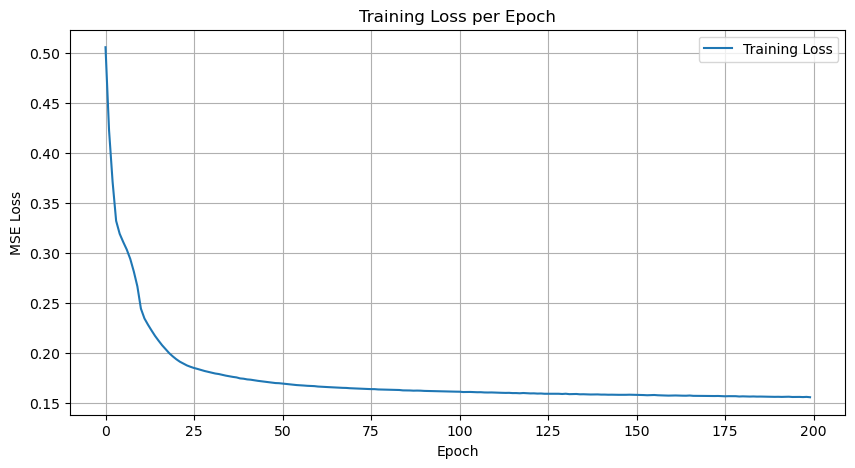

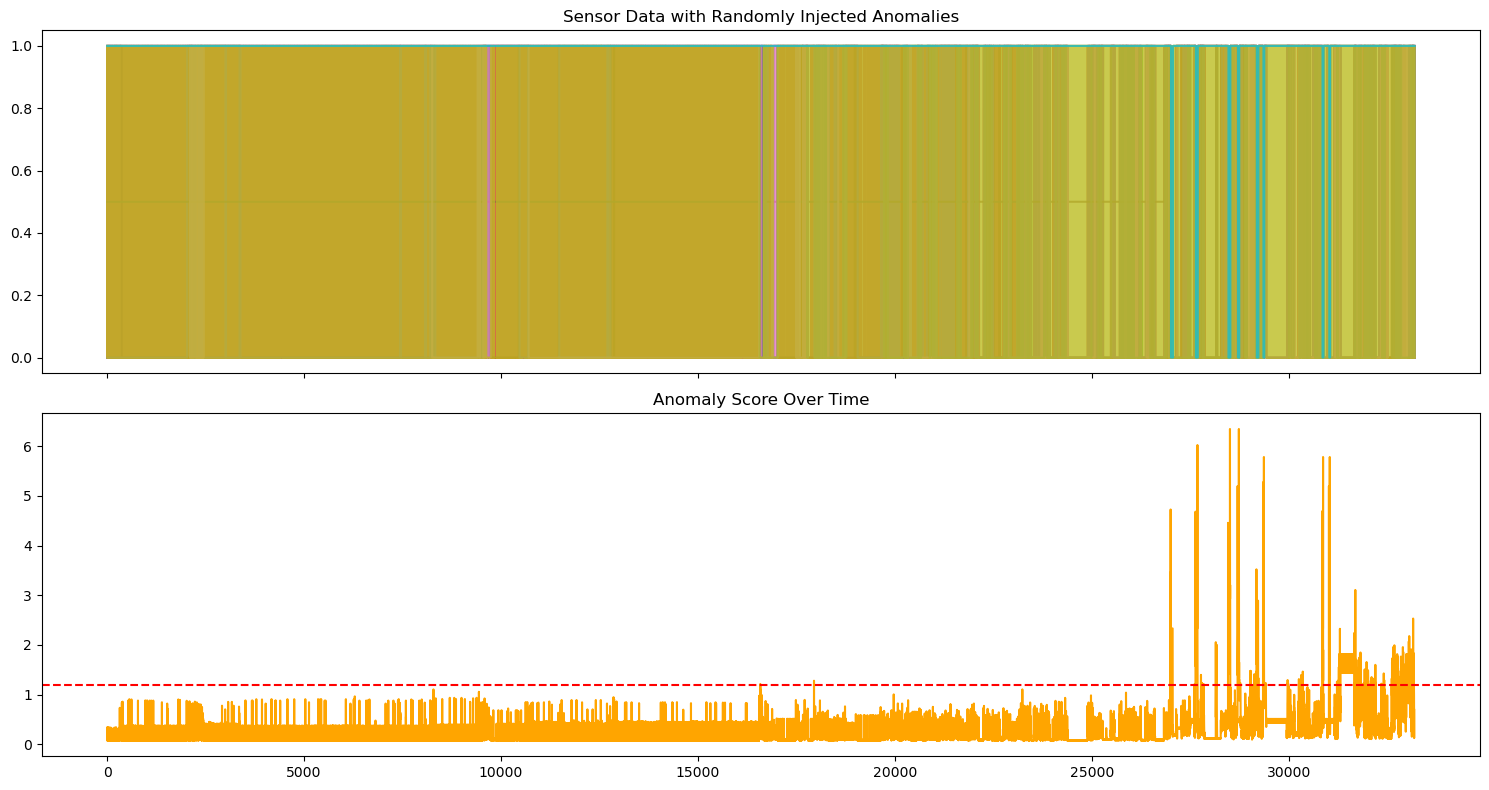

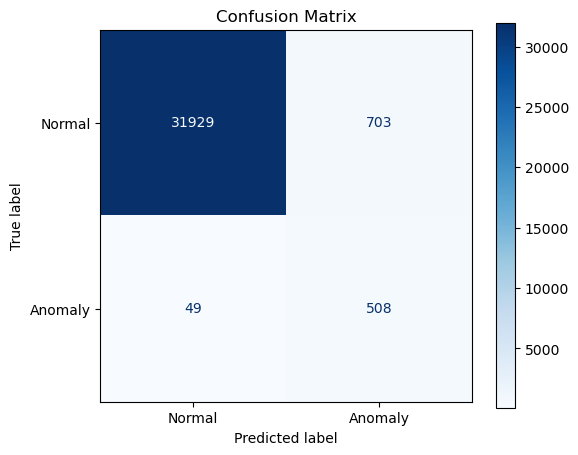

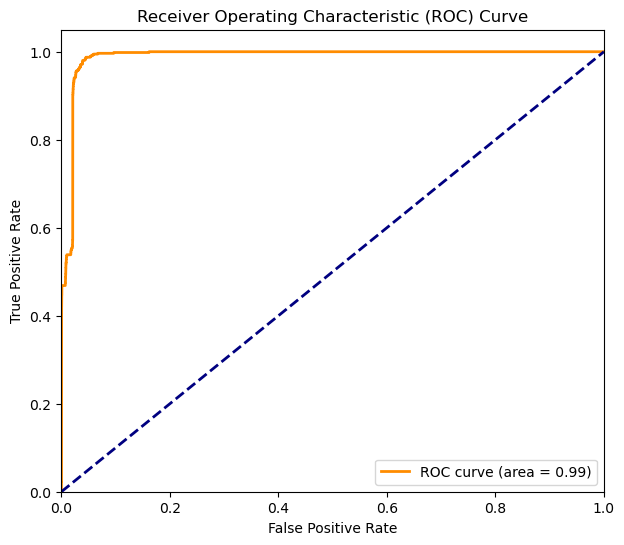

In [15]:
# Determine threshold from normal training data
train_scores = anomaly_scores[:len(train_data) - WINDOW_SIZE]
threshold = np.mean(train_scores) + 8 * np.std(train_scores)

# --- ÃƒÂ°Ã…Â¸Ã¢â‚¬Å“Ã…Â  Evaluation Section ÃƒÂ°Ã…Â¸Ã¢â‚¬Å“Ã…Â  ---
print("\n--- Model Evaluation ---")

# Align predictions with ground truth labels
# Predictions start after the first window
test_predictions = (anomaly_scores > threshold).astype(int)
test_ground_truth = ground_truth_labels[WINDOW_SIZE:]

# Calculate metrics
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_ground_truth, test_predictions, average='binary'
)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")

# MODIFICATION 3: Add a plot for the training loss
fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
ax_loss.plot(loss_history, label='Training Loss')
ax_loss.set_title('Training Loss per Epoch')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('MSE Loss')
ax_loss.legend()
ax_loss.grid(True)

# --- Plotting ---
# 1. Plot Sensor Data and Anomaly Scores
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
ax1.plot(data, alpha=0.8, drawstyle='steps-post')
ax1.set_title("Sensor Data with Randomly Injected Anomalies")
ax2.plot(anomaly_scores, color='orange', label='Anomaly Score (BCE Loss)')
ax2.axhline(threshold, color='red', linestyle='--', label='Threshold')
ax2.set_title("Anomaly Score Over Time")
plt.tight_layout()

# 2. Plot Confusion Matrix
cm = confusion_matrix(test_ground_truth, test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
fig2, ax_cm = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax_cm, cmap='Blues')
ax_cm.set_title('Confusion Matrix')

# 3. Plot ROC Curve
fpr, tpr, _ = roc_curve(test_ground_truth, anomaly_scores)
roc_auc = auc(fpr, tpr)
fig3, ax_roc = plt.subplots(figsize=(7, 6))
ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
ax_roc.legend(loc="lower right")

savefigs = [fig_loss, fig1, fig2, fig3]
# for i, fig in enumerate(savefigs, 1):
#     fig.savefig(f'./Plots/Graph-Learning/Lab/plot_BCE_Loss_{i}.png')
plt.show()

ÃƒÂ°Ã…Â¸Ã¢â‚¬ÂÃ¢â‚¬Å¾ Loading and synchronizing adjacency matrix...
ÃƒÂ¢Ã…â€œÃ¢â‚¬Â¦ Adjacency matrix synchronized.
ÃƒÂ°Ã…Â¸Ã¢â‚¬â„¢Ã¢â‚¬Â° Injecting 100 random anomalies...
Data shape before anomaly injection: (13280, 10), anomalies to inject: 100
anomalous data shape: (13280, 10), labels shape: (13280,)
Number of anomalies injected: 3186.0
ÃƒÂ°Ã…Â¸Ã¢â‚¬â€Ã‚ÂºÃƒÂ¯Ã‚Â¸Ã‚Â Training with PREDEFINED graph structure...
Epoch 10/100, Average Loss: 0.338557
Epoch 20/100, Average Loss: 0.315916
Epoch 30/100, Average Loss: 0.292978
Epoch 40/100, Average Loss: 0.279390
Epoch 50/100, Average Loss: 0.274211
Epoch 60/100, Average Loss: 0.269452
Epoch 70/100, Average Loss: 0.263690
Epoch 80/100, Average Loss: 0.264283
Epoch 90/100, Average Loss: 0.255627
Epoch 100/100, Average Loss: 0.260133
ÃƒÂ¢Ã…â€œÃ¢â‚¬Â¦ Training complete.

--- Model Evaluation ---
Precision: 0.5708
Recall:    0.9900
F1-Score:  0.7241


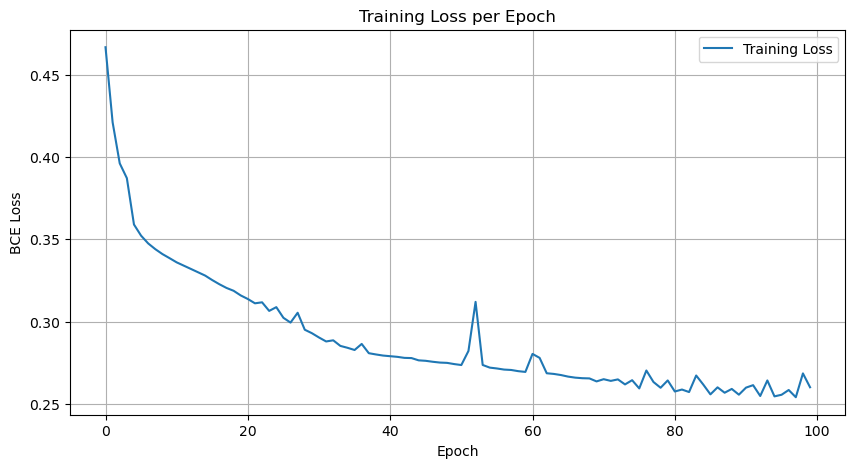

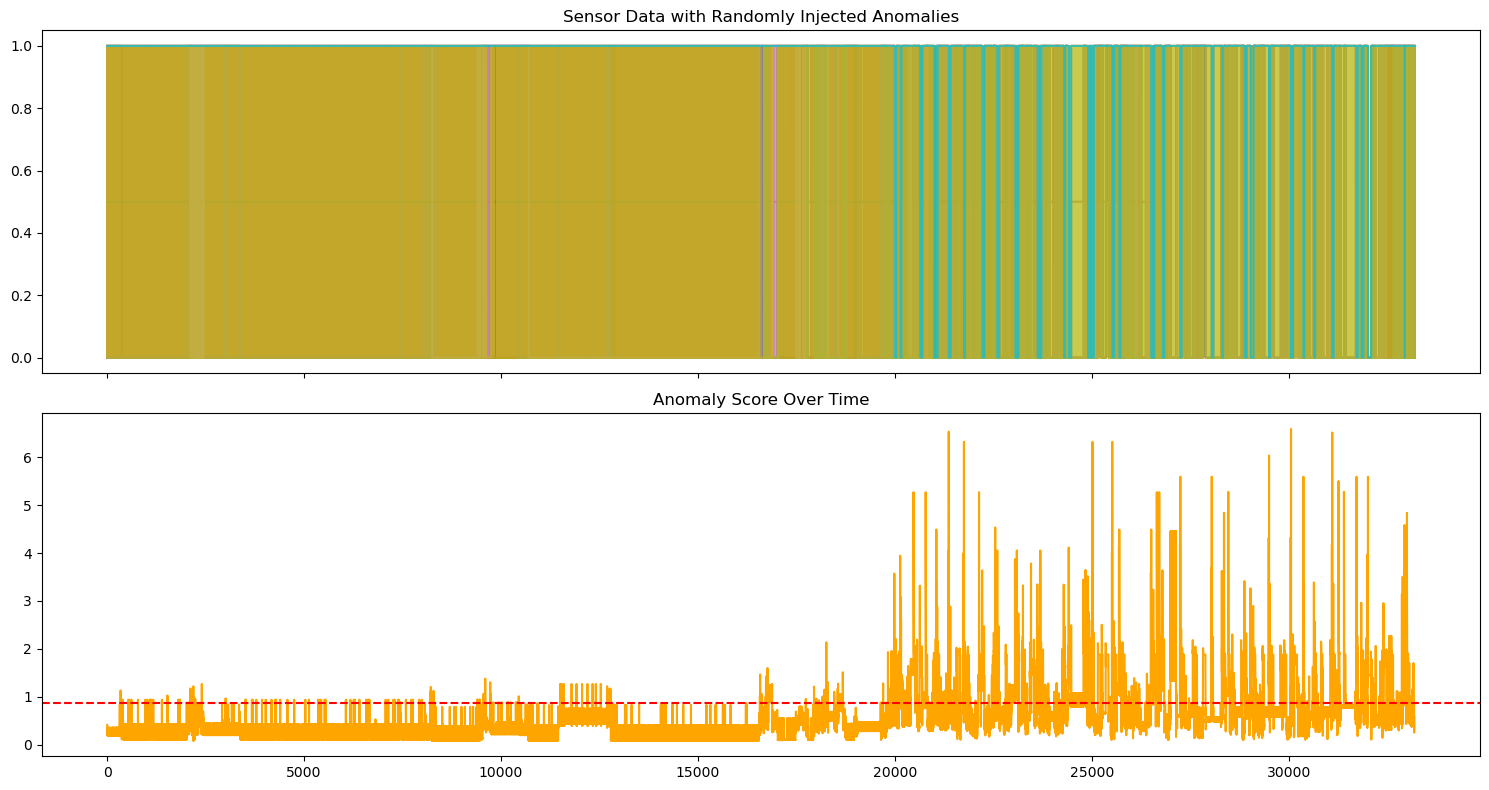

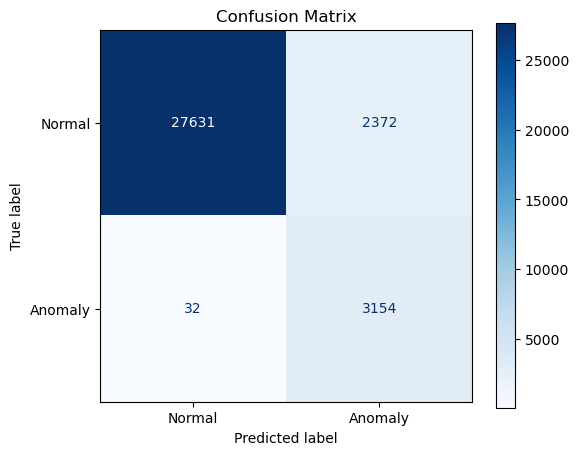

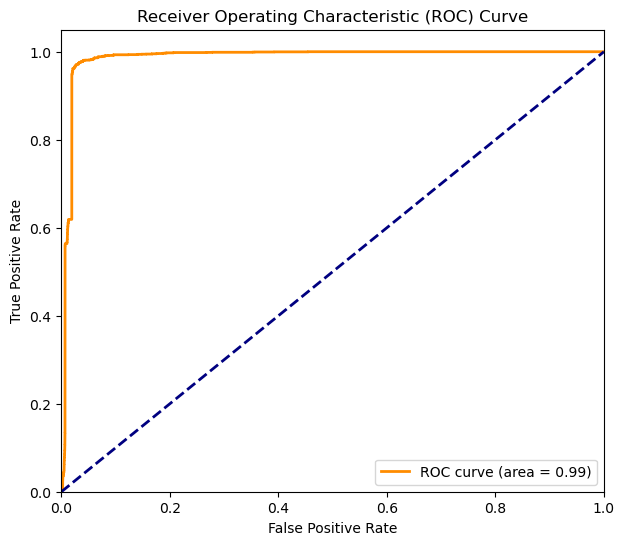

In [ ]:
# --- Main Execution ---
if __name__ == '__main__':
    # --- Create a sample CSV in memory to simulate your file ---
#     sample_csv_data = """date;time;seconds;state;sensor_name;thing_name;thing_ip;thing_ip0
# 2025-09-16;15:00;0;0;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;0;1;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;0;0;SENSOR_C;device2;192.168.1.11;eth0
# 2025-09-16;15:00;1;1;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;1;0;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;1;0;SENSOR_C;device2;192.168.1.11;eth0
# 2025-09-16;15:00;2;0;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;2;1;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;2;1;SENSOR_C;device2;192.168.1.11;eth0
# 2025-09-16;15:00;3;0;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;3;1;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;3;0;SENSOR_C;device2;192.168.1.11;eth0
# """
#     # In your real code, you would use: file_path = "your_data.csv"
#     csv_buffer = io.StringIO(sample_csv_data)
    
    # Load and process the data
    # data, sensor_names = load_and_preprocess_data(csv_buffer)
    # --- Configuration ---
    # ÃƒÂ°Ã…Â¸Ã¢â‚¬â„¢Ã‚Â¡ SET THIS TO True OR False TO SWITCH MODELS
    LEARN_GRAPH = False 
    
    

    # Inject random anomalies to create the full dataset and ground truth labels
    # data, ground_truth_labels = inject_random_anomalies(data_array, num_anomalies=100)
    regular_data = data_array ## Original normal data
    NUM_SENSORS = regular_data.shape[1]
    WINDOW_SIZE = NUM_SENSORS
    # NUM_SENSORS = data_array.shape[1]
    # adj_csv_buffer = pd.read_csv('Data/adjacency_matrices/fne_matrix_norm.csv')
    adj_matrix = load_and_synchronize_adj_matrix('Data/adjacency_matrices/lab_fne_matrix_norm.csv', sensor_names)
    # adj_matrix =[[]]

    edge_index = torch.tensor(np.array(np.where(adj_matrix)), dtype=torch.long)

    # --- Data Splitting and Preparation ---
    TRAIN_SPLIT = int(len(regular_data) * 0.6) # Use first 80% for training
    train_data = regular_data[:TRAIN_SPLIT] # Training data is always normal

    # Test data includes anomalies
    test_data = regular_data[TRAIN_SPLIT:]
    test_data_anomalies, test_truth_labels = inject_random_anomalies(test_data, num_anomalies=100)

    ## Combine train and test data for evaluation
    data = np.vstack([train_data, test_data_anomalies])
    ground_truth_labels = np.hstack([np.zeros(len(train_data)), test_truth_labels])
    
    sequences, targets = create_sliding_windows(train_data, WINDOW_SIZE)
    train_dataset = TensorDataset(torch.tensor(sequences, dtype=torch.float32), 
                                  torch.tensor(targets, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # --- Model Selection and Training ---
    if LEARN_GRAPH:
        print("ÃƒÂ°Ã…Â¸Ã‚Â§Ã‚Â  Training with LEARNABLE graph structure...")
        model = GNN_LearnableGraph(num_sensors=NUM_SENSORS)
    else:
        print("ÃƒÂ°Ã…Â¸Ã¢â‚¬â€Ã‚ÂºÃƒÂ¯Ã‚Â¸Ã‚Â Training with PREDEFINED graph structure...")
        model = SpatioTemporalGNN2(num_sensors=NUM_SENSORS)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.BCEWithLogitsLoss()
    # criterion = nn.MSELoss()

    # Create a list to store loss history
    loss_history = []
    epochs = 100
    for epoch in range(epochs):
        epoch_loss = 0.0
        num_batches = 0
        for seq, target in train_loader:
            optimizer.zero_grad()
            if LEARN_GRAPH:
                output_logits = model(seq)
            else:
                output_logits = model(seq, edge_index)
            loss = criterion(output_logits, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1
        
        # MODIFICATION 2: Save the average loss for the epoch
        avg_epoch_loss = epoch_loss / num_batches
        loss_history.append(avg_epoch_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_epoch_loss:.6f}")

    print("  Training complete.")

    # --- Inference and Anomaly Scoring ---
    model.eval()
    all_sequences, all_targets = create_sliding_windows(data, WINDOW_SIZE)
    with torch.no_grad():
        if LEARN_GRAPH:
            prediction_logits = model(torch.tensor(all_sequences, dtype=torch.float32))
        else:
            prediction_logits = model(torch.tensor(all_sequences, dtype=torch.float32), edge_index)

    loss_fn = nn.BCEWithLogitsLoss(reduction='none')
    # loss_fn = nn.MSELoss(reduction='none')
    anomaly_scores = loss_fn(prediction_logits, torch.tensor(all_targets, dtype=torch.float32)).mean(axis=1).numpy()
    
    # Determine threshold from normal training data
    train_scores = anomaly_scores[:len(train_data) - WINDOW_SIZE]
    threshold = np.mean(train_scores) + 3 * np.std(train_scores)

    # --- ÃƒÂ°Ã…Â¸Ã¢â‚¬Å“Ã…Â  Evaluation Section ÃƒÂ°Ã…Â¸Ã¢â‚¬Å“Ã…Â  ---
    print("\n--- Model Evaluation ---")
    
    # Align predictions with ground truth labels
    # Predictions start after the first window
    test_predictions = (anomaly_scores > threshold).astype(int)
    test_ground_truth = ground_truth_labels[WINDOW_SIZE:]

    # Calculate metrics
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        test_ground_truth, test_predictions, average='binary'
    )
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1_score:.4f}")

    # MODIFICATION 3: Add a plot for the training loss
    fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
    ax_loss.plot(loss_history, label='Training Loss')
    ax_loss.set_title('Training Loss per Epoch')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('BCE Loss')
    ax_loss.legend()
    ax_loss.grid(True)

    # --- Plotting ---
    # 1. Plot Sensor Data and Anomaly Scores
    fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    ax1.plot(data, alpha=0.8, drawstyle='steps-post')
    ax1.set_title("Sensor Data with Randomly Injected Anomalies")
    ax2.plot(anomaly_scores, color='orange', label='Anomaly Score (BCE Loss)')
    ax2.axhline(threshold, color='red', linestyle='--', label='Threshold')
    ax2.set_title("Anomaly Score Over Time")
    plt.tight_layout()
    
    # 2. Plot Confusion Matrix
    cm = confusion_matrix(test_ground_truth, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
    fig2, ax_cm = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax_cm, cmap='Blues')
    ax_cm.set_title('Confusion Matrix')

    # 3. Plot ROC Curve
    fpr, tpr, _ = roc_curve(test_ground_truth, anomaly_scores)
    roc_auc = auc(fpr, tpr)
    fig3, ax_roc = plt.subplots(figsize=(7, 6))
    ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax_roc.legend(loc="lower right")
    # plt.savefig('./Plots/Graph-Learning/roc-graph-no-learning.png', dpi=300)

    savefigs = [fig_loss, fig1, fig2, fig3]
    # for i, fig in enumerate(savefigs, 1):
    #     fig.savefig(f'./Plots/Graph-No-Learning/Lab/evaluation_plot_BCE_Loss_{i}_epoch100.png')
    plt.show()


--- Model Evaluation ---
Precision: 0.8321
Recall:    0.9554
F1-Score:  0.8895


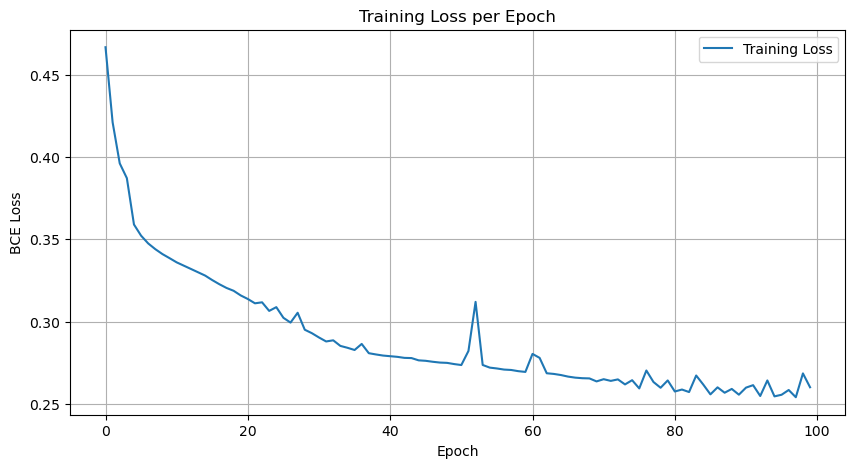

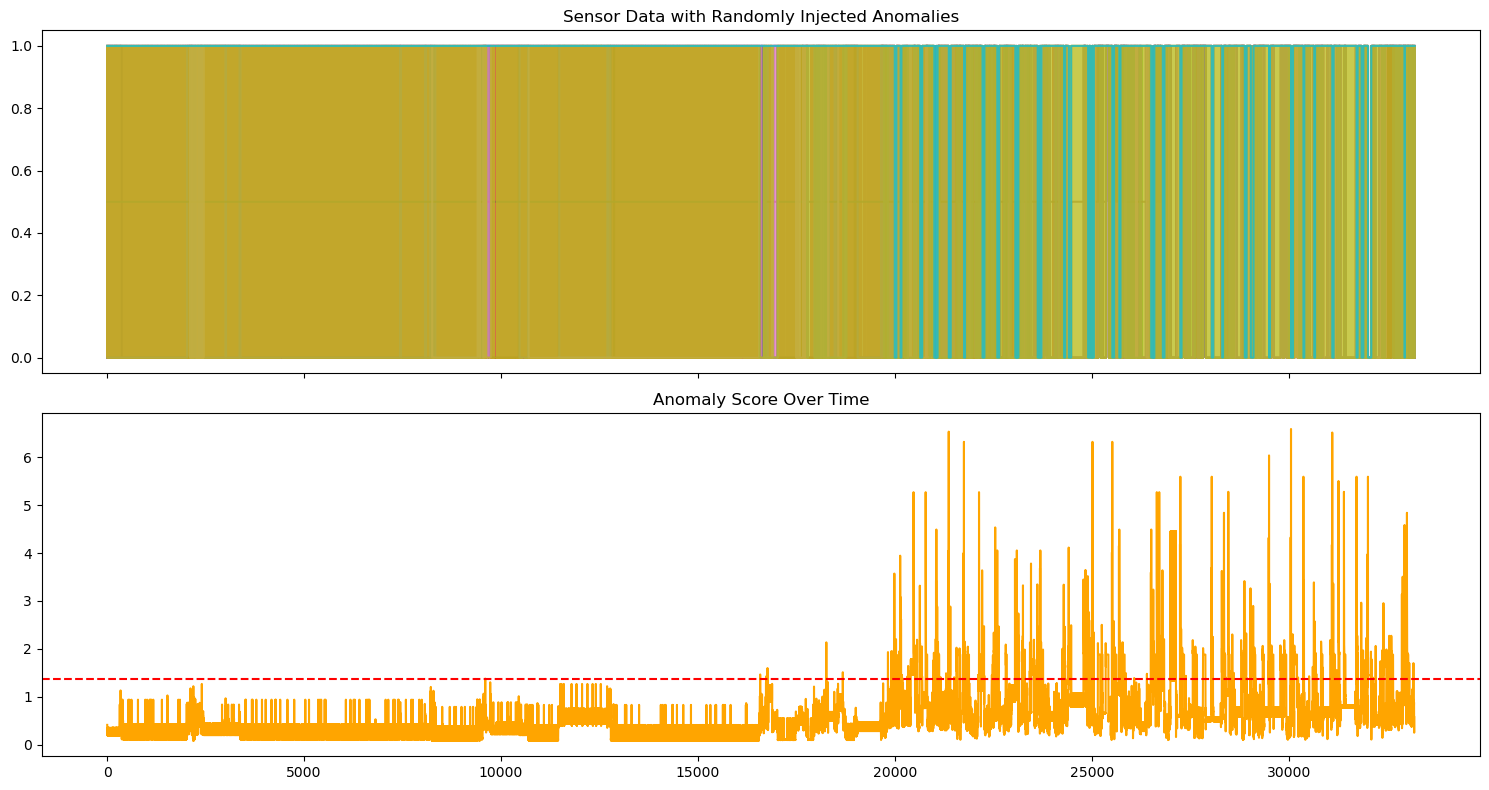

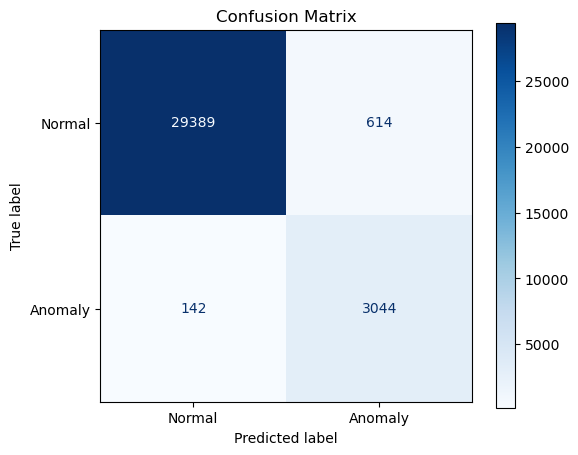

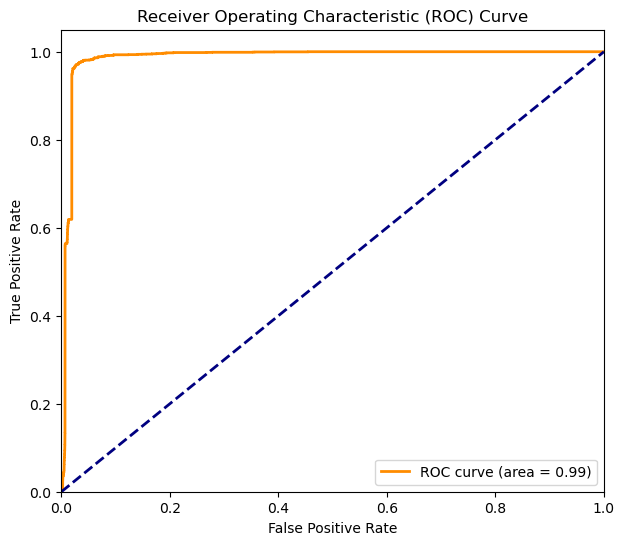

In [31]:
# Determine threshold from normal training data
train_scores = anomaly_scores[:len(train_data) - WINDOW_SIZE]
threshold = np.mean(train_scores) + 5.5 * np.std(train_scores)

# --- ÃƒÂ°Ã…Â¸Ã¢â‚¬Å“Ã…Â  Evaluation Section ÃƒÂ°Ã…Â¸Ã¢â‚¬Å“Ã…Â  ---
print("\n--- Model Evaluation ---")

# Align predictions with ground truth labels
# Predictions start after the first window
test_predictions = (anomaly_scores > threshold).astype(int)
test_ground_truth = ground_truth_labels[WINDOW_SIZE:]

# Calculate metrics
precision, recall, f1_score, _ = precision_recall_fscore_support(
test_ground_truth, test_predictions, average='binary'
)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")

# MODIFICATION 3: Add a plot for the training loss
fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
ax_loss.plot(loss_history, label='Training Loss')
ax_loss.set_title('Training Loss per Epoch')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('BCE Loss')
ax_loss.legend()
ax_loss.grid(True)

# --- Plotting ---
# 1. Plot Sensor Data and Anomaly Scores
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
ax1.plot(data, alpha=0.8, drawstyle='steps-post')
ax1.set_title("Sensor Data with Randomly Injected Anomalies")
ax2.plot(anomaly_scores, color='orange', label='Anomaly Score (BCE Loss)')
ax2.axhline(threshold, color='red', linestyle='--', label='Threshold')
ax2.set_title("Anomaly Score Over Time")
plt.tight_layout()

# 2. Plot Confusion Matrix
cm = confusion_matrix(test_ground_truth, test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
fig2, ax_cm = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax_cm, cmap='Blues')
ax_cm.set_title('Confusion Matrix')

# 3. Plot ROC Curve
fpr, tpr, _ = roc_curve(test_ground_truth, anomaly_scores)
roc_auc = auc(fpr, tpr)
fig3, ax_roc = plt.subplots(figsize=(7, 6))
ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
ax_roc.legend(loc="lower right")
# plt.savefig('./Plots/Graph-Learning/roc-graph-no-learning.png', dpi=300)

savefigs = [fig_loss, fig1, fig2, fig3]
for i, fig in enumerate(savefigs, 1):
    fig.savefig(f'./Plots/Graph-No-Learning/Lab/evaluation_plot_BCE_Loss_{i}_small_training.png')
plt.show()

ÃƒÂ°Ã…Â¸Ã¢â‚¬ÂÃ¢â‚¬Å¾ Loading and synchronizing adjacency matrix...
ÃƒÂ¢Ã…â€œÃ¢â‚¬Â¦ Adjacency matrix synchronized.
ÃƒÂ°Ã…Â¸Ã¢â‚¬â„¢Ã¢â‚¬Â° Injecting 50 random anomalies...
Data shape before anomaly injection: (6640, 10), anomalies to inject: 50
anomalous data shape: (6640, 10), labels shape: (6640,)
Number of anomalies injected: 1539.0
ÃƒÂ°Ã…Â¸Ã‚Â§Ã‚Â  Training with HYBRID (Initialize & Fine-Tune) graph structure...
ÃƒÂ°Ã…Â¸Ã…Â¡Ã¢â€šÂ¬ Starting model training...
Epoch 10/100, Average Loss: 0.184862
Epoch 20/100, Average Loss: 0.170257
Epoch 30/100, Average Loss: 0.164516
Epoch 40/100, Average Loss: 0.164206
Epoch 50/100, Average Loss: 0.163609
Epoch 60/100, Average Loss: 0.161975
Epoch 70/100, Average Loss: 0.183101
Epoch 80/100, Average Loss: 0.187420
Epoch 90/100, Average Loss: 0.176323
Epoch 100/100, Average Loss: 0.169965
ÃƒÂ¢Ã…â€œÃ¢â‚¬Â¦ Training complete.

--- Model Evaluation ---
Precision: 0.1805
Recall:    0.1501
F1-Score:  0.1639


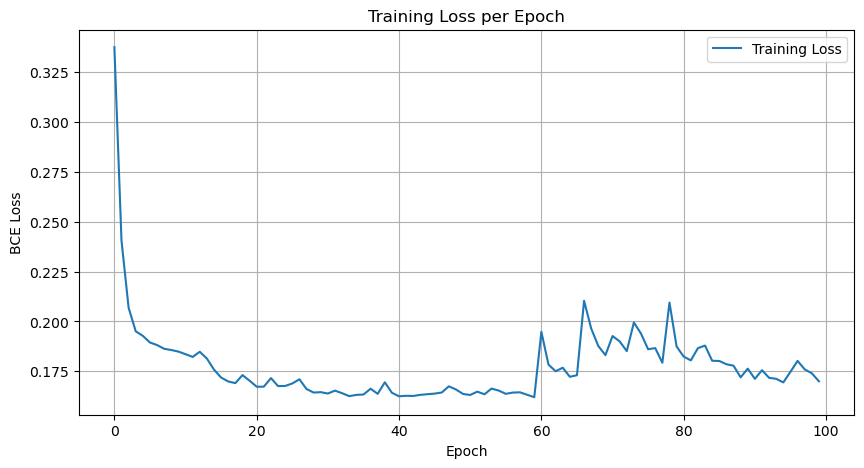

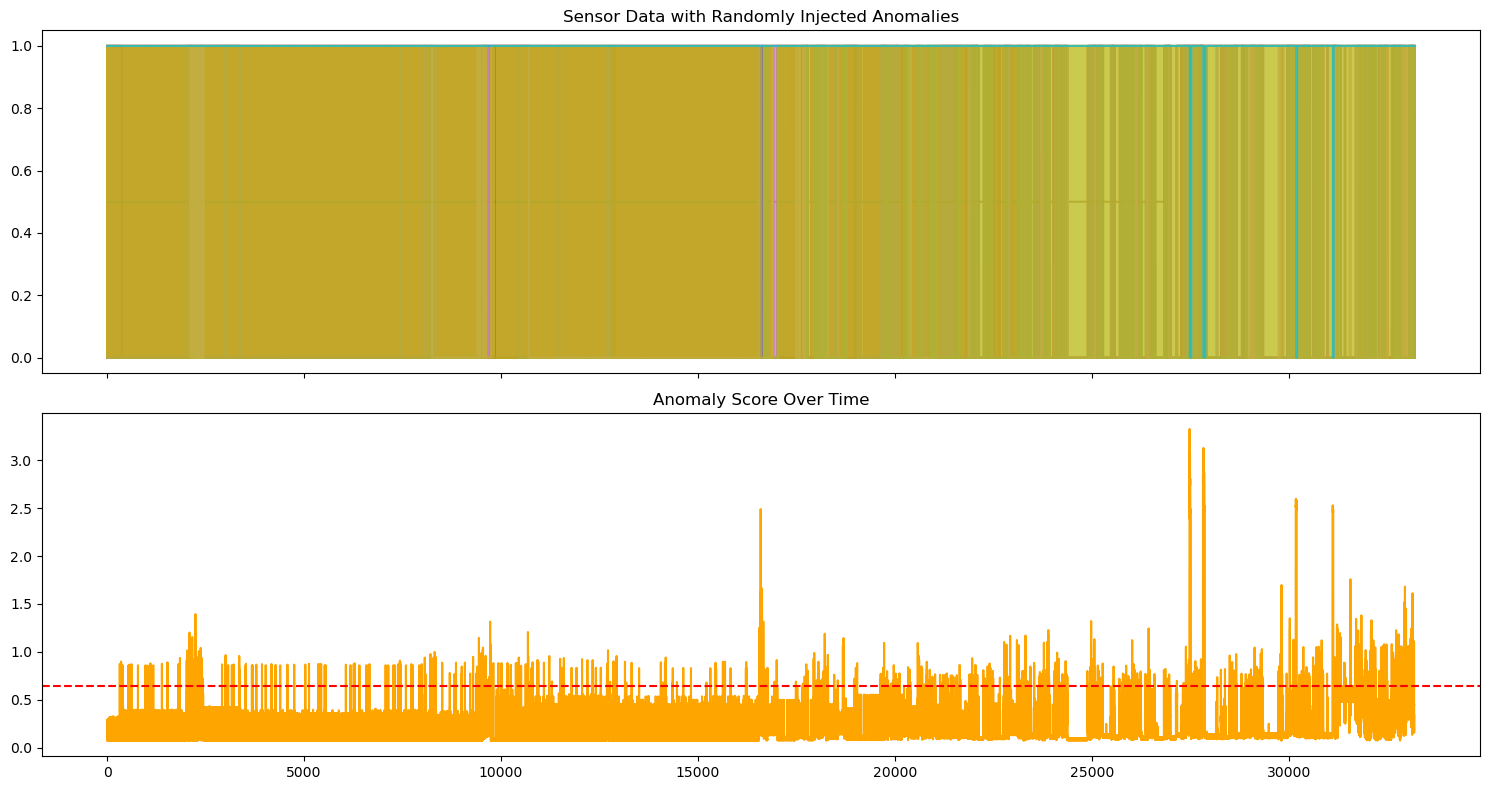

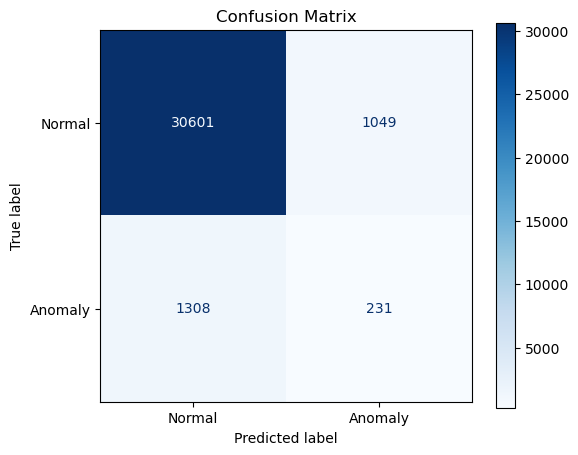

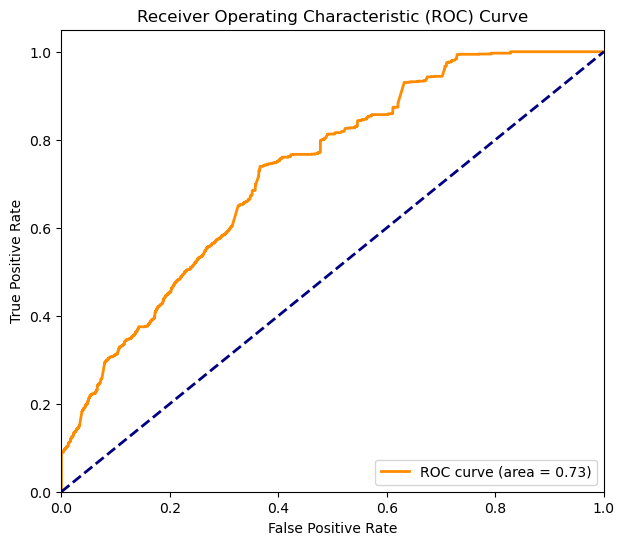

In [ ]:
if __name__ == '__main__':
    # --- Device Configuration ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    normal_data_base = data_array  # Use the preprocessed data from earlier
    NUM_SENSORS = normal_data_base.shape[1]
    
    # --- Adjacency Matrix and Edge Index Preparation ---
    predefined_adj_matrix = load_and_synchronize_adj_matrix('Data/adjacency_matrices/fne_matrix_norm.csv', sensor_names)

    # --- Data Splitting ---
    TRAIN_SPLIT = int(len(normal_data_base) * 0.8) 
    train_data = normal_data_base[:TRAIN_SPLIT]
    test_data_normal = normal_data_base[TRAIN_SPLIT:]
    test_data_anomalies, test_labels = inject_random_anomalies(test_data_normal, num_anomalies=50)
    data = np.concatenate((train_data, test_data_anomalies), axis=0)
    ground_truth_labels = np.concatenate((np.zeros(len(train_data)), test_labels), axis=0)
    
    sequences, targets = create_sliding_windows(train_data, NUM_SENSORS)
    train_dataset = TensorDataset(torch.tensor(sequences, dtype=torch.float32), 
                                  torch.tensor(targets, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # --- Model Selection and Training ---
    print("ÃƒÂ°Ã…Â¸Ã‚Â§Ã‚Â  Training with HYBRID (Initialize & Fine-Tune) graph structure...")
    # MODIFICATION 3: Instantiate the GNN_LearnableGraph model with the predefined matrix
    model = GNN_LearnableGraph_Initialized(num_sensors=NUM_SENSORS, initial_adj_matrix=predefined_adj_matrix).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.BCEWithLogitsLoss()
    
    loss_history = []
    epochs = 100
    print("ÃƒÂ°Ã…Â¸Ã…Â¡Ã¢â€šÂ¬ Starting model training...")
    for epoch in range(epochs):
        epoch_loss = 0.0
        num_batches = 0
        for seq, target in train_loader:
            optimizer.zero_grad()
            seq, target = seq.to(device), target.to(device)
            # The model automatically uses its learnable, initialized matrix
            output_logits = model(seq)
            loss = criterion(output_logits, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1
        avg_epoch_loss = epoch_loss / num_batches
        loss_history.append(avg_epoch_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_epoch_loss:.6f}")
    print("  Training complete.")

    # --- Inference and Evaluation (same as before) ---
    model.eval()
    all_sequences, all_targets = create_sliding_windows(data, NUM_SENSORS)
    with torch.no_grad():
        all_sequences_tensor = torch.tensor(all_sequences, dtype=torch.float32).to(device)
        all_targets_tensor = torch.tensor(all_targets, dtype=torch.float32).to(device)
        prediction_logits = model(all_sequences_tensor)
            
    loss_fn = nn.BCEWithLogitsLoss(reduction='none')
    anomaly_scores = loss_fn(prediction_logits, all_targets_tensor).mean(axis=1).cpu().numpy()
    train_scores = anomaly_scores[:len(train_data) - NUM_SENSORS]
    threshold = np.mean(train_scores) + 3 * np.std(train_scores)

    print("\n--- Model Evaluation ---")
    test_predictions = (anomaly_scores > threshold).astype(int)
    test_ground_truth = ground_truth_labels[NUM_SENSORS:]
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        test_ground_truth, test_predictions, average='binary'
    )
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1_score:.4f}")
    cm = confusion_matrix(test_ground_truth, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
    
    fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
    ax_loss.plot(loss_history, label='Training Loss')
    ax_loss.set_title('Training Loss per Epoch')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('BCE Loss')
    ax_loss.legend()
    ax_loss.grid(True)
    
    fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    ax1.set_title("Sensor Data with Randomly Injected Anomalies")
    ax1.plot(data, alpha=0.8, drawstyle='steps-post')
    ax2.plot(anomaly_scores, color='orange', label='Anomaly Score (BCE Loss)')
    ax2.axhline(threshold, color='red', linestyle='--', label='Threshold')
    ax2.set_title('Anomaly Score Over Time')
    plt.tight_layout()
    
    fig2, ax_cm = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax_cm, cmap='Blues')
    ax_cm.set_title('Confusion Matrix')
    fpr, tpr, _ = roc_curve(test_ground_truth, anomaly_scores)
    roc_auc = auc(fpr, tpr)
    fig3, ax_roc = plt.subplots(figsize=(7, 6))
    ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax_roc.legend(loc="lower right")
    plt.show()

In [28]:
from torchinfo import summary

# --- Inside your main `if __name__ == '__main__':` block ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ... after model instantiation ...
model = SpatioTemporalGNN(num_sensors=NUM_SENSORS).to(device)
print(f"Using device: {device}")

# --- FIX IS HERE ---
# 1. Define sample input shapes
BATCH_SIZE = 32 # Use a typical batch size
WINDOW_SIZE = 10 # Must match your model's window size
# NUM_SENSORS = data.shape[1]
NUM_SENSORS = 100

# 2. Create sample input tensors on the correct device
sample_x = torch.randn(BATCH_SIZE, WINDOW_SIZE, NUM_SENSORS).to(device)
# sample_edge_index is just your 'edge_index' tensor
sample_edge_index = edge_index.to(device) 

# 3. Call summary() with input_data
# Pass a tuple containing all arguments for the forward method
print("\n--- Model Summary (SpatioTemporalGNN) ---")
print(summary(model, input_data=(sample_x, sample_edge_index)))
# --- END OF FIX ---
print("\n --- Model Summary (Learnable GNN) --- ")
print(summary(GNN_LearnableGraph(num_sensors=NUM_SENSORS).to(device), input_data=(sample_x,)))

Using device: cuda

--- Model Summary (SpatioTemporalGNN) ---
Layer (type:depth-idx)                   Output Shape              Param #
SpatioTemporalGNN                        [32, 10]                  --
ÃƒÂ¢Ã¢â‚¬ÂÃ…â€œÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬GCNConv: 1-1                           [3200, 16]                16
ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬Å¡    ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬ÂÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬Linear: 2-1                       [3200, 16]                16
ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬Å¡    ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬ÂÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬SumAggregation: 2-2               [3200, 16]                --
ÃƒÂ¢Ã¢â‚¬ÂÃ…â€œÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬GCNConv: 1-2                           [3200, 16]                (recursive)
ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬Å¡    ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬ÂÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬Linear: 2-3                       [3200, 16]                (recursive)
ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬Å¡    ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬ÂÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬SumAggregation: 2-4               [3200, 16]                --
ÃƒÂ¢Ã¢â‚¬ÂÃ…â€œÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬GCNConv: 1-3                           [3200, 16]    

In [ ]:
import torch.profiler

# --- 1. New Function: Sparse Matrix Generator ---
def create_sparse_adj_matrix(num_sensors, num_neighbors):
    """
    Creates a sparse, symmetric adjacency matrix for a given number of sensors,
    where each sensor has approximately num_neighbors.
    """
    print(f"  Creating sparse adjacency matrix for {num_sensors} sensors...")
    # Start with an empty N x N matrix
    adj_matrix = np.zeros((num_sensors, num_sensors), dtype=int)
    
    # Create N * K connections
    # 'row_indices' will be [0,0...0, 1,1...1, ...] (K times for each)
    row_indices = np.repeat(np.arange(num_sensors), num_neighbors)
    # 'col_indices' will be N*K random sensor indices
    col_indices = np.random.randint(0, num_sensors, size=num_sensors * num_neighbors)
    
    # Apply the connections
    adj_matrix[row_indices, col_indices] = 1
    
    # Make the graph symmetric (undirected)
    adj_matrix[col_indices, row_indices] = 1
    
    # Remove self-loops
    np.fill_diagonal(adj_matrix, 0)
    
    num_edges = np.sum(adj_matrix)
    print(f"  Matrix created with {num_edges} total edges (connections).")
    return adj_matrix

NUM_SENSORS = 1000
WINDOW_SIZE = 10
BATCH_SIZE = 32
# --- Create sample data ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_predefined = SpatioTemporalGNN(num_sensors=NUM_SENSORS).to(device)
model_predefined_updated = SpatioTemporalGNN2(num_sensors=NUM_SENSORS).to(device)
model_learnable = GNN_LearnableGraph(num_sensors=NUM_SENSORS).to(device) 

adj_matrix = create_sparse_adj_matrix(NUM_SENSORS, num_neighbors=4)

sample_x = torch.randn(BATCH_SIZE, WINDOW_SIZE, NUM_SENSORS).to(device)
sample_edge_index = torch.tensor(np.array(np.where(adj_matrix)), dtype=torch.long).to(device)

# --- Profile the Predefined (Sparse) Model ---
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
    record_shapes=True
) as prof:
    with torch.profiler.record_function("model_inference"):
        _ = model_predefined(sample_x, sample_edge_index)

print("--- Profiler Results for Predefined (Sparse) Model ---")
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=10))

# --- Profile the Updated Predefined (Sparse) Model ---
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
    record_shapes=True
) as prof:
    with torch.profiler.record_function("model_inference"):
        _ = model_predefined_updated(sample_x, sample_edge_index)

print("\n--- Profiler Results for Updated Predefined (Sparse) Model ---")
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=10))


# --- Profile the Learnable (Dense)Model ---
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
    record_shapes=True
) as prof:
    with torch.profiler.record_function("model_inference"):
        _ = model_learnable(sample_x)

print("\n--- Profiler Results for Learnable (Dense) Model ---")
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=10))

ÃƒÂ°Ã…Â¸Ã¢â‚¬ÂÃ¢â‚¬Å¾ Creating sparse adjacency matrix for 1000 sensors...
ÃƒÂ¢Ã…â€œÃ¢â‚¬Â¦ Matrix created with 7970 total edges (connections).
--- Profiler Results for Predefined (Sparse) Model ---
-----------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                         Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-----------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
              model_inference         4.18%      12.360ms       100.00%     295.690ms     295.690ms      16.540ms         5.11%     323.751ms     323.751ms             1  
                  aten::index         0.66%       1.964ms        87.21%     257.869ms       8.596ms       9.140

In [16]:
from torchinfo import summary
from torch_geometric.nn import GATConv # Import GATConv


class GATLSTM_PredefinedGraph(nn.Module):
    def __init__(self, num_sensors, seq_len, hidden_dim, out_features, heads=1):
        super().__init__()
        self.num_sensors = num_sensors
        
        # GATConv expects (in_channels, out_channels)
        # in_channels: features per node (which is SEQ_LENGTH in our case)
        # out_channels: output features per node after GATConv
        self.gat = GATConv(in_channels=seq_len, out_channels=hidden_dim, heads=heads, concat=True, dropout=0.2)
        
        # LSTM input will be (num_sensors * hidden_dim * heads) if concat=True
        # We process the entire graph's output as one sequence element for LSTM
        self.lstm = nn.LSTM(input_size=num_sensors * hidden_dim * heads, hidden_size=hidden_dim, num_layers=1, batch_first=True)
        self.linear = nn.Linear(hidden_dim, out_features * num_sensors)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x, edge_index):
        # x shape: (batch_size, seq_len, num_sensors)
        batch_size, seq_len, _ = x.shape
        
        # Reshape for GATConv: (num_nodes, num_features)
        # For each sample in the batch, we process it through GATConv
        gat_outputs = []
        for i in range(batch_size):
            # Input to GATConv: (num_sensors, seq_len)
            x_sample = x[i].T # Transpose to (num_sensors, seq_len)
            
            gat_out = self.dropout(self.relu(self.gat(x_sample, edge_index)))
            gat_outputs.append(gat_out)
        
        gat_outputs = torch.stack(gat_outputs) # (batch_size, num_sensors, hidden_dim * heads)
        
        # Flatten for LSTM: (batch_size, 1, num_sensors * hidden_dim * heads)
        lstm_input = gat_outputs.reshape(batch_size, 1, -1)
        
        lstm_out, _ = self.lstm(lstm_input)
        last_time_step = lstm_out[:, -1, :] # Take last time step's output
        
        out = self.linear(last_time_step)
        return out.reshape(batch_size, self.num_sensors)

# 1. Define sample input shapes
BATCH_SIZE = 32 # Use a typical batch size
WINDOW_SIZE = 10 # Must match your model's window size
# NUM_SENSORS = data.shape[1]
NUM_SENSORS = 10

# --- Inside your main `if __name__ == '__main__':` block ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ... after model instantiation ...
model = SpatioTemporalGNN(num_sensors=NUM_SENSORS).to(device)
model_predefined_updated = SpatioTemporalGNN2(num_sensors=NUM_SENSORS).to(device)
model_learnable = GNN_LearnableGraph(num_sensors=NUM_SENSORS).to(device)
model_attention = GATLSTM_PredefinedGraph(num_sensors=NUM_SENSORS, seq_len=WINDOW_SIZE, hidden_dim=16, out_features=1, heads=2).to(device)
print(f"Using device: {device}")


adj_matrix = create_sparse_adj_matrix(NUM_SENSORS, num_neighbors=4)
# 2. Create sample input tensors on the correct device
sample_x = torch.randn(BATCH_SIZE, WINDOW_SIZE, NUM_SENSORS).to(device)
# sample_edge_index is just your 'edge_index' tensor
sample_edge_index = torch.tensor(np.array(np.where(adj_matrix)), dtype=torch.long).to(device) 

# 3. Call summary() with input_data
# Pass a tuple containing all arguments for the forward method
print("\n--- Model Summary (SpatioTemporalGNN) ---")
print(summary(model, input_data=(sample_x, sample_edge_index)))

print("\n--- Model Summary (SpatioTemporalGNN2) ---")
print(summary(model_predefined_updated, input_data=(sample_x, sample_edge_index)))
# --- END OF FIX ---
print("\n --- Model Summary (Learnable GNN) --- ")
print(summary(model_learnable, input_data=(sample_x,)))

print("\n --- Model Summary (GAT + LSTM) --- ")
print(summary(model_attention, input_data=(sample_x, sample_edge_index)))

Using device: cuda
ÃƒÂ°Ã…Â¸Ã¢â‚¬ÂÃ¢â‚¬Å¾ Creating sparse adjacency matrix for 10 sensors...
ÃƒÂ¢Ã…â€œÃ¢â‚¬Â¦ Matrix created with 44 total edges (connections).

--- Model Summary (SpatioTemporalGNN) ---
Layer (type:depth-idx)                   Output Shape              Param #
SpatioTemporalGNN                        [32, 10]                  --
ÃƒÂ¢Ã¢â‚¬ÂÃ…â€œÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬GCNConv: 1-1                           [320, 16]                 16
ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬Å¡    ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬ÂÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬Linear: 2-1                       [320, 16]                 16
ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬Å¡    ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬ÂÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬SumAggregation: 2-2               [320, 16]                 --
ÃƒÂ¢Ã¢â‚¬ÂÃ…â€œÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬GCNConv: 1-2                           [320, 16]                 (recursive)
ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬Å¡    ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬ÂÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬Linear: 2-3                       [320, 16]                 (recursive)
ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬Å¡    ÃƒÂ¢Ã¢â‚¬ÂÃ¢â‚¬ÂÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬SumAggreg

In [9]:
# ============================================================
# ABLATION PREPARATION
# Two fixes to make graph structure differences measurable:
#
# 1. SpatioTemporalGNN2_Ablation: GCNConv with add_self_loops=False
#    so the identity graph (self-loops only) produces true zero
#    cross-sensor aggregation, and random/predefined are not
#    artificially boosted by GCNConv implicit self-loop addition.
#
# 2. inject_selective_anomalies: robust single-sensor faults so
#    spatial graph structure matters for detecting the faulty sensor.
# ============================================================

# ------------------------------------------------------------------
# 1. Modified model: GCNConv with add_self_loops=False
# ------------------------------------------------------------------
class SpatioTemporalGNN2_Ablation(nn.Module):
    """Identical to SpatioTemporalGNN2 but with add_self_loops=False.
    Self-loops must be encoded explicitly in edge_index to be used."""
    def __init__(self, num_sensors, gcn_hidden_dim=16, rnn_hidden_dim=32):
        super(SpatioTemporalGNN2_Ablation, self).__init__()
        self.gcn = GCNConv(in_channels=1, out_channels=gcn_hidden_dim,
                           add_self_loops=False)
        self.rnn = nn.GRU(input_size=gcn_hidden_dim, hidden_size=rnn_hidden_dim,
                          batch_first=True)
        self.fc = nn.Linear(rnn_hidden_dim, num_sensors)

    def forward(self, x, edge_index):
        batch_size, window_size, num_sensors = x.shape
        batch_edge_index = edge_index.repeat(1, batch_size) + \
                           torch.arange(batch_size, device=x.device).repeat_interleave(
                               edge_index.size(1)) * num_sensors
        gcn_out_seq = []
        for t in range(window_size):
            snapshot = x[:, t, :].reshape(-1, 1)
            gcn_out = self.gcn(snapshot, batch_edge_index)
            gcn_out = gcn_out.reshape(batch_size, num_sensors, -1)
            gcn_out_seq.append(gcn_out)
        gcn_outputs = torch.stack(gcn_out_seq, dim=1)
        rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(
            batch_size * num_sensors, window_size, -1)
        _, h_n = self.rnn(rnn_input)
        rnn_out = h_n.squeeze(0).reshape(batch_size, num_sensors, -1)
        graph_embedding = rnn_out.mean(dim=1)
        return self.fc(graph_embedding)


# ------------------------------------------------------------------
# 2. Robust spatially selective anomaly injection
# ------------------------------------------------------------------
def inject_selective_anomalies(data, num_anomalies=50,
                                min_duration=30, max_duration=60,
                                window_size=4):
    """
    Robust single-sensor fault injection with three guarantees:

    1. Anti-modal stuck value: injected value is always the OPPOSITE
       of the sensor's dominant state (mode), guaranteeing a clear
       contrast with normal behaviour rather than accidentally matching it.

    2. Non-overlapping segments: an occupancy mask prevents anomaly
       windows from touching, keeping every timestep unambiguously
       normal or anomalous Ã¢â‚¬â€ no partial or compound windows.

    3. Duration >= window_size: each anomaly spans at least one full
       sliding window so the model always sees a complete abnormal
       snapshot, never a clipped one at a boundary.
    """
    print(f"Injecting {num_anomalies} robust single-sensor anomalies...")
    anomalous_data = data.copy()
    labels     = np.zeros(len(data))
    n_sensors  = data.shape[1]

    # Mode per sensor over the full segment (binary data: round of mean)
    sensor_modes = np.round(data.mean(axis=0)).astype(int)

    occupied     = np.zeros(len(data), dtype=bool)
    injected     = 0
    attempts     = 0
    max_attempts = num_anomalies * 20
    eff_min      = max(min_duration, window_size)   # guarantee 3

    while injected < num_anomalies and attempts < max_attempts:
        attempts  += 1
        duration   = np.random.randint(eff_min, max_duration)
        start_idx  = np.random.randint(0, len(data) - duration)

        if occupied[start_idx : start_idx + duration].any():  # guarantee 2
            continue

        sensor_idx  = np.random.randint(0, n_sensors)
        stuck_value = 1 - sensor_modes[sensor_idx]            # guarantee 1

        anomalous_data[start_idx : start_idx + duration, sensor_idx] = stuck_value
        labels[start_idx : start_idx + duration]                      = 1
        occupied[start_idx : start_idx + duration]                    = True
        injected += 1

    if injected < num_anomalies:
        print(f"  Warning: only {injected}/{num_anomalies} placed "
              f"(test segment too short or density too high).")
    else:
        print(f"  Done. {injected} anomalies, {int(labels.sum())} anomalous steps.")
    return anomalous_data, labels


# ------------------------------------------------------------------
# 3. Rebuild data split for the ablation (80/20, robust anomalies)
#    Overwrites train_data / data / ground_truth_labels / train_loader
#    so the ablation cell below uses consistent, meaningful data.
# ------------------------------------------------------------------
_abl_prep_data  = data_array
_abl_prep_split = int(len(_abl_prep_data) * 0.8)
train_data      = _abl_prep_data[:_abl_prep_split]
_abl_test_raw   = _abl_prep_data[_abl_prep_split:]
_abl_win        = data_array.shape[1]          # 4: WINDOW_SIZE = NUM_SENSORS

_abl_test_anom, _abl_test_labels = inject_selective_anomalies(
    _abl_test_raw, num_anomalies=50, window_size=_abl_win)

data                = np.vstack([train_data, _abl_test_anom])
ground_truth_labels = np.hstack([np.zeros(len(train_data)), _abl_test_labels])

_abl_seqs, _abl_tgts = create_sliding_windows(train_data, _abl_win)
_abl_dataset  = TensorDataset(torch.tensor(_abl_seqs, dtype=torch.float32),
                               torch.tensor(_abl_tgts, dtype=torch.float32))
train_loader  = DataLoader(_abl_dataset, batch_size=32, shuffle=True)

print(f"Ablation data ready Ã¢â‚¬â€ train: {len(train_data)}, "
      f"total: {len(data)}, anomaly steps: {int(ground_truth_labels.sum())}")

Injecting 50 robust single-sensor anomalies...
  Done. 50 anomalies, 2098 anomalous steps.
Ablation data ready Ã¢â‚¬â€ train: 26776, total: 33471, anomaly steps: 2098


Ablation setup â€” sensors: 10, window: 10
Edge counts â€” identity: 10, random: 94, predefined: 96, learned: (parameter)

  Variant: identity
  Epoch 10/100  avg_loss=0.415466
  Epoch 20/100  avg_loss=0.406469
  Epoch 30/100  avg_loss=0.404519
  Epoch 40/100  avg_loss=0.403333
  Epoch 50/100  avg_loss=0.402502
  Epoch 60/100  avg_loss=0.401869
  Epoch 70/100  avg_loss=0.401350
  Epoch 80/100  avg_loss=0.400931
  Epoch 90/100  avg_loss=0.400516
  Epoch 100/100  avg_loss=0.400167
  Training complete.
  Precision=0.3729  Recall=0.1468  F1=0.2107  ROC-AUC=0.7946

  Variant: random
  Epoch 10/100  avg_loss=0.361816
  Epoch 20/100  avg_loss=0.322224
  Epoch 30/100  avg_loss=0.350519
  Epoch 40/100  avg_loss=0.321524
  Epoch 50/100  avg_loss=0.314002
  Epoch 60/100  avg_loss=0.336094
  Epoch 70/100  avg_loss=0.315879
  Epoch 80/100  avg_loss=0.310894
  Epoch 90/100  avg_loss=0.303730
  Epoch 100/100  avg_loss=0.302203
  Training complete.
  Precision=0.3949  Recall=0.1616  F1=0.2294  ROC-AUC

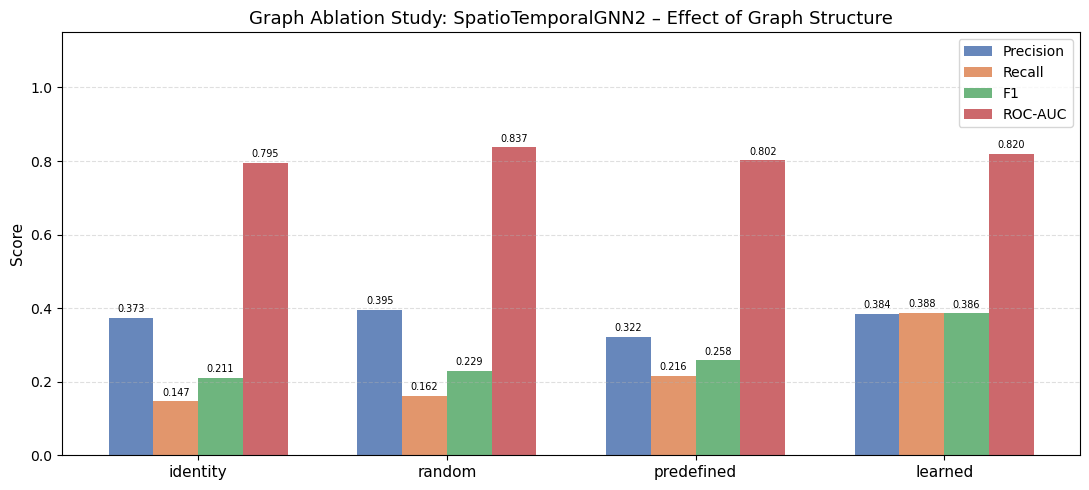

In [7]:
# ============================================================
# GRAPH ABLATION STUDY â€“ SpatioTemporalGNN2
# Tests 4 graph structure variants: identity, random,
# predefined (same as original), learned (GNN_LearnableGraph).
# All loop-local variables prefixed _ to avoid shadowing the
# notebook namespace (model, optimizer, criterion, etc.).
# ============================================================

# Derive actual sensor count and window size from the data,
# since later cells override NUM_SENSORS and WINDOW_SIZE.
_NUM_SENSORS = data_array.shape[1]
_abl_seq_sample, _ = next(iter(train_loader))
_WINDOW_SIZE = _abl_seq_sample.shape[1]

# Self-loop edges shared across variants that need them
_self_loops_idx = torch.stack(
    [torch.arange(_NUM_SENSORS, dtype=torch.long),
     torch.arange(_NUM_SENSORS, dtype=torch.long)], dim=0)

# ------------------------------------------------------------------
# Build graph variants
# ------------------------------------------------------------------

# Identity: self-loops only â€” zero cross-sensor communication
# (serves as the lower-bound baseline)
_identity_edge_index = _self_loops_idx.clone()

# Random: same off-diagonal edge density as predefined, fixed seed,
# PLUS explicit self-loops so the comparison is fair (every variant
# has self-connections; the only difference is the neighbourhood structure)
_adj_pred_np = np.zeros((_NUM_SENSORS, _NUM_SENSORS), dtype=np.float32)
_adj_pred_np[edge_index[0].numpy(), edge_index[1].numpy()] = 1.0
_n_undirected = max(1, int(np.triu(_adj_pred_np, k=1).sum()))
_rng_abl = np.random.default_rng(42)
_rand_pairs = set()
while len(_rand_pairs) < _n_undirected:
    _i = int(_rng_abl.integers(0, _NUM_SENSORS))
    _j = int(_rng_abl.integers(0, _NUM_SENSORS))
    if _i != _j:
        _rand_pairs.add((min(_i, _j), max(_i, _j)))
_rand_adj = np.zeros((_NUM_SENSORS, _NUM_SENSORS), dtype=np.float32)
for _pi, _pj in _rand_pairs:
    _rand_adj[_pi, _pj] = _rand_adj[_pj, _pi] = 1.0
_random_edge_index = torch.cat([
    torch.tensor(np.array(np.where(_rand_adj)), dtype=torch.long),
    _self_loops_idx
], dim=1)

# Predefined: existing edge_index + explicit self-loops
# Self-loops are added here because the ablation model uses
# add_self_loops=False; without them, predefined would miss the
# self-connections that the original GCNConv (add_self_loops=True)
# added automatically â€” this ensures predefined truly replicates
# the original SpatioTemporalGNN2 behaviour.
_predefined_edge_index = torch.cat([edge_index, _self_loops_idx], dim=1)

print(f"Ablation setup â€” sensors: {_NUM_SENSORS}, window: {_WINDOW_SIZE}")
print(f"Edge counts â€” identity: {_identity_edge_index.shape[1]}, "
      f"random: {_random_edge_index.shape[1]}, "
      f"predefined: {_predefined_edge_index.shape[1]}, "
      f"learned: (parameter)")

# ------------------------------------------------------------------
# Ablation variants: (name, model, edge_index or None)
# identity/random/predefined  ->  SpatioTemporalGNN2_Ablation (add_self_loops=False)
# learned                     ->  GNN_LearnableGraph (no edge_index)
# ------------------------------------------------------------------
_ablation_variants = [
    ('identity',   SpatioTemporalGNN2_Ablation(num_sensors=_NUM_SENSORS),  _identity_edge_index),
    ('random',     SpatioTemporalGNN2_Ablation(num_sensors=_NUM_SENSORS),  _random_edge_index),
    ('predefined', SpatioTemporalGNN2_Ablation(num_sensors=_NUM_SENSORS),  _predefined_edge_index),
    ('learned',    GNN_LearnableGraph(num_sensors=_NUM_SENSORS),           None),
]

_abl_criterion = nn.BCEWithLogitsLoss()
_abl_loss_fn   = nn.BCEWithLogitsLoss(reduction='none')
_abl_epochs    = 100
_abl_lr        = 0.0005
_abl_results   = {}

# ------------------------------------------------------------------
# Training and evaluation loop
# ------------------------------------------------------------------
for _var_name, _abl_model, _var_ei in _ablation_variants:
    print(f"\n{'='*55}")
    print(f"  Variant: {_var_name}")
    print(f"{'='*55}")

    _abl_opt = torch.optim.Adam(_abl_model.parameters(), lr=_abl_lr)

    # Training (identical hyperparameters to original SpatioTemporalGNN2 cell)
    _abl_model.train()
    for _epoch in range(_abl_epochs):
        _epoch_loss = 0.0
        _n_batches  = 0
        for _seq, _tgt in train_loader:
            _abl_opt.zero_grad()
            _out = _abl_model(_seq) if _var_ei is None else _abl_model(_seq, _var_ei)
            _loss = _abl_criterion(_out, _tgt)
            _loss.backward()
            _abl_opt.step()
            _epoch_loss += _loss.item()
            _n_batches  += 1
        if (_epoch + 1) % 10 == 0:
            print(f"  Epoch {_epoch+1}/{_abl_epochs}  "
                  f"avg_loss={_epoch_loss / _n_batches:.6f}")
    print("  Training complete.")

    # Evaluation (identical to original SpatioTemporalGNN2 cell)
    _abl_model.eval()
    _all_seqs, _all_tgts = create_sliding_windows(data, _WINDOW_SIZE)
    _all_seqs_t = torch.tensor(_all_seqs, dtype=torch.float32)
    _all_tgts_t = torch.tensor(_all_tgts, dtype=torch.float32)
    with torch.no_grad():
        _logits = _abl_model(_all_seqs_t) if _var_ei is None else _abl_model(_all_seqs_t, _var_ei)
    _scores = _abl_loss_fn(_logits, _all_tgts_t).mean(axis=1).numpy()

    _train_scores = _scores[:len(train_data) - _WINDOW_SIZE]
    _threshold    = np.mean(_train_scores) + 3 * np.std(_train_scores)
    _preds        = (_scores > _threshold).astype(int)
    _gt           = ground_truth_labels[_WINDOW_SIZE:]

    _p, _r, _f, _ = precision_recall_fscore_support(
        _gt, _preds, average='binary', zero_division=0
    )
    _fpr, _tpr, _ = roc_curve(_gt, _scores)
    _roc_auc      = auc(_fpr, _tpr)

    _abl_results[_var_name] = {
        'Precision': float(_p),
        'Recall':    float(_r),
        'F1':        float(_f),
        'ROC-AUC':   float(_roc_auc),
    }
    print(f"  Precision={_p:.4f}  Recall={_r:.4f}  "
          f"F1={_f:.4f}  ROC-AUC={_roc_auc:.4f}")

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
_abl_df = pd.DataFrame(_abl_results).T
_abl_df.index.name = 'Variant'
print("\n" + "=" * 60)
print("  GRAPH ABLATION STUDY â€“ SUMMARY")
print("=" * 60)
print(_abl_df.round(4).to_string())
print("=" * 60)

# ------------------------------------------------------------------
# Bar chart: Precision / Recall / F1 / ROC-AUC per variant
# ------------------------------------------------------------------
_metrics_plot = ['Precision', 'Recall', 'F1', 'ROC-AUC']
_vars_plot    = list(_abl_results.keys())
_x            = np.arange(len(_vars_plot))
_w            = 0.18
_bar_colors   = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

_fig_abl, _ax_abl = plt.subplots(figsize=(11, 5))
for _mi, (_metric, _color) in enumerate(zip(_metrics_plot, _bar_colors)):
    _vals = [_abl_results[v][_metric] for v in _vars_plot]
    _bars = _ax_abl.bar(_x + _mi * _w, _vals, _w, label=_metric,
                        color=_color, alpha=0.85)
    for _bar, _val in zip(_bars, _vals):
        _ax_abl.text(
            _bar.get_x() + _bar.get_width() / 2,
            _bar.get_height() + 0.01,
            f'{_val:.3f}',
            ha='center', va='bottom', fontsize=7
        )

_ax_abl.set_xticks(_x + _w * 1.5)
_ax_abl.set_xticklabels(_vars_plot, fontsize=11)
_ax_abl.set_ylim(0, 1.15)
_ax_abl.set_ylabel('Score', fontsize=11)
_ax_abl.set_title('Graph Ablation Study: SpatioTemporalGNN2 â€“ Effect of Graph Structure',
                  fontsize=13)
_ax_abl.legend(loc='upper right', fontsize=10)
_ax_abl.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()